In [1]:
import os, sys
from pathlib import Path
from pprint import pprint
from collections import defaultdict

import torch
import numpy as np
import pandas as pd
import scipy as sp
from tqdm import tqdm
import matplotlib.pyplot as plt
import yaml

# RESULTS_DIR = Path.cwd() / 'results'
BASE_DIR = Path.cwd().resolve().parent.parent
DATA_DIR = BASE_DIR / 'data'
SMD_DIR = DATA_DIR / 'server_machine_dataset'
SMD_TRAIN_DIR = SMD_DIR / 'train'
SMD_TEST_DIR = SMD_DIR / 'test'
SMD_TEST_LABEL_DIR = SMD_DIR / 'test_label'
SMD_TEST_INTERPRETATION_LABEL_DIR = SMD_DIR / 'interpretation_label'
SCRIPT_DIR = Path.cwd().resolve()
CFG_DIR = SCRIPT_DIR / 'configs'
RESULTS_DIR = SCRIPT_DIR / 'results'


sys.path.append(BASE_DIR.as_posix())

from data.server_machine_dataset import SMDMachineChannel
from data.nyc_taxi_dataset import NYCTaxiDataset
from data.hsi_abu_dataset import ABUHyperSpectral

from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from src.multilinear_ops.matricize import matricize
from src.multilinear_ops.tensorize import tensorize

plt.style.use('seaborn-v0_8-paper')
# Set the default font family to serif
plt.rcParams['font.family'] = 'serif' 
# Specify a list of font names to try for the serif family
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Palatino'] 

## Saving Tensorized SMD Dataset as .mat file for MATLAB based Methods

In [2]:
machines = [1,2,3]
machine_num_channels = {
    1: 8, # Machine id: Number of channels
    2: 9,
    3: 11,
}
variance_estimates = pd.read_csv(RESULTS_DIR / 'rank_and_variance_estimates.csv', index_col=[0,1,2]
                                    ).loc['R2']['variance_estimate'].to_dict()
smd_dataset = {
    'machine_ids': np.array([1,2,3]),
    'num_channels': np.array([8,9,11]),
    'data': {
        'm1': {
            f"ch{i}" : SMDMachineChannel(1, i).Y for i in range(1, 8+1)
            },
        'm2': {
            f"ch{i}"  : SMDMachineChannel(2, i).Y for i in range(1, 9+1)
            },
        'm3': {
            f"ch{i}"  : SMDMachineChannel(3, i).Y for i in range(1, 11+1)
            },
    },
    'var_est': {
        'm1': {
            f"ch{i}" : variance_estimates[(1,i)] for i in range(1, 8+1)
            },
        'm2': {
            f"ch{i}" : variance_estimates[(2,i)] for i in range(1, 9+1)
            },
        'm3': {
            f"ch{i}" : variance_estimates[(3,i)] for i in range(1, 11+1)
            },
    },
}

name = './results/tensorized_data/tensorized_smd.mat'
sp.io.savemat(name, smd_dataset)

In [27]:
mchannel = SMDMachineChannel(1, 1)
res = sp.io.loadmat('OITNN_m1_ch1.mat')
S = res['Shat']
scoring_score = mchannel.anomaly_scoring_score(np.abs(S))
scoring_score.pop('st_scores', None)
scoring_score.pop('t_scores', None)
s = S.ravel()
q1 = np.quantile(s, 0.25)
q2 = np.median(s)
q3 = np.quantile(s, 0.75)
iqr = q3 - q1
outlier_labels = (S < q1 - 1.5*iqr) | (S > q3 + 1.5*iqr)
detection_score = mchannel.anomaly_detection_score(outlier_labels)
pprint(scoring_score)
pprint(detection_score)

{'au_prc': 0.3438454972979239, 'au_roc': 0.6315346235121418}
{'PA_F1': 0.17284188239822923,
 'PA_precision': 0.09459601811861372,
 'PA_recall': 1.0,
 'f1': 0.17284188239822923,
 'group_accuracy': 1.0,
 'group_support_ratio': np.float64(0.1869525742362743),
 'precision': 0.09459601811861372,
 'recall': 1.0}


In [3]:
res['Shat'].shape

(24, 7, 53, 81)

In [7]:
mchannel = NYCTaxiDataset()
res = sp.io.loadmat('OITNN_nyc.mat')
S = np.moveaxis(res['Shat'], (0,1,2,3),(3,2,1,0))
scoring_score = mchannel.anomaly_scoring_score(np.abs(S))
scoring_score.pop('st_scores', None)
scoring_score.pop('t_scores', None)
# s = S.ravel()
# q1 = np.quantile(s, 0.25)
# q2 = np.median(s)
# q3 = np.quantile(s, 0.75)
# iqr = q3 - q1
# outlier_labels = (S < q1 - 1.5*iqr) | (S > q3 + 1.5*iqr)
# detection_score = mchannel.anomaly_detection_score(outlier_labels)
print(scoring_score)
# pprint(detection_score)

defaultdict(<class 'list'>, {'ratios': [0.00014, 0.0007, 0.0014, 0.003, 0.007, 0.01, 0.02, 0.03], 'num_detected_events': [0, 0, 1, 2, 2, 2, 6, 8], 'detected_events': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]], 'total_detected_support_ratio': [0.0, 0.0, 0.007575757575757576, 0.022727272727272728, 0.045454545454545456, 0.05303030303030303, 0.11363636363636363, 0.1590909090909091], 'total_detected_events': 21})


In [3]:
mchannel = NYCTaxiDataset()
res = sp.io.loadmat('RTD-OITNN-L_nyc.mat')
S = np.moveaxis(res['Shat'], (0,1,2,3),(3,2,1,0))
scoring_score = mchannel.anomaly_scoring_score(np.abs(S))
print(scoring_score)

print(f"Model: {'':<15} # Detected Anomalies:")
print("-"*80)
model_name = 'RTD-OITNN-L |S|'
print(f"{model_name:<30} {scoring_score['num_detected_events']}")
S = mchannel.Y-np.moveaxis(res['Lhat'], (0,1,2,3),(3,2,1,0))
scoring_score = mchannel.anomaly_scoring_score(np.abs(S))
model_name = 'RTD-OITNN-L |Y-X|'
print(f"{model_name:<30} {scoring_score['num_detected_events']}")
# pprint(detection_score)

defaultdict(<class 'list'>, {'ratios': [0.00014, 0.0007, 0.0014, 0.003, 0.007, 0.01, 0.02, 0.03], 'num_detected_events': [1, 1, 1, 1, 3, 4, 6, 8], 'detected_events': [[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0], [1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], [1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1]], 'total_detected_support_ratio': [0.015151515151515152, 0.022727272727272728, 0.022727272727272728, 0.022727272727272728, 0.03787878787878788, 0.06818181818181818, 0.12121212121212122, 0.1590909090909091], 'total_detected_events': 25})
Model:                 # Detected Anomalies:
--------------------------------------------------------

In [2]:
mchannel = NYCTaxiDataset()
res = sp.io.loadmat('RTD-OITNN-O_nyc.mat')
S = np.moveaxis(res['Shat'], (0,1,2,3),(3,2,1,0))
scoring_score = mchannel.anomaly_scoring_score(np.abs(S))
print(scoring_score)

print(f"Model: {'':<15} # Detected Anomalies:")
print("-"*80)
model_name = 'RTD-OITNN-O |S|'
print(f"{model_name:<30} {scoring_score['num_detected_events']}")
S = mchannel.Y-np.moveaxis(res['Lhat'], (0,1,2,3),(3,2,1,0))
scoring_score = mchannel.anomaly_scoring_score(np.abs(S))
model_name = 'RTD-OITNN-O |Y-X|'
print(f"{model_name:<30} {scoring_score['num_detected_events']}")
# pprint(detection_score)

defaultdict(<class 'list'>, {'ratios': [0.00014, 0.0007, 0.0014, 0.003, 0.007, 0.01, 0.02, 0.03], 'num_detected_events': [0, 0, 1, 2, 2, 2, 6, 8], 'detected_events': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]], 'total_detected_support_ratio': [0.0, 0.0, 0.007575757575757576, 0.022727272727272728, 0.045454545454545456, 0.05303030303030303, 0.11363636363636363, 0.1590909090909091], 'total_detected_events': 21})
Model:                 # Detected Anomalies:
--------------------------------------------------------------------------------
RTD-OITN

In [ ]:
mchannel = NYCTaxiDataset()
res = sp.io.loadmat('RTD-TRPCA_nyc.mat')
# S = mchannel.Y-np.moveaxis(res['Ltrpca'], (0,1,2,3),(3,2,1,0))
S = np.moveaxis(res['Strpca'], (0,1,2,3),(3,2,1,0))
scoring_score = mchannel.anomaly_scoring_score(np.abs(S))

print(f"Model: {'':<28} # Detected Anomalies:")
print("-"*80)
model_name = 'RTD-TRPCA |S|'
print(f"{model_name:<30} {scoring_score['num_detected_events']}")
S = mchannel.Y-np.moveaxis(res['Ltrpca'], (0,1,2,3),(3,2,1,0))
scoring_score = mchannel.anomaly_scoring_score(np.abs(S))
model_name = 'RTD-TRPCA |Y-X|'
print(f"{model_name:<30} {scoring_score['num_detected_events']}")
# pprint(detection_score)

Model:                 # Detected Anomalies:
--------------------------------------------------------------------------------
RTD-TRPCA |S|                  [0, 1, 3, 4, 9, 13, 16, 16]
RTD-TRPCA |Y-X|                [0, 1, 3, 4, 9, 13, 16, 18]


## SMD Results

In [24]:
res = sp.io.loadmat('./results/smd_matlab_alg_results.mat')
keys = res['model_keys']
model_keys = [str(keys[0,i][0]) for i in range(len(keys[0]))]
model_names = []
for k in model_keys:
    model_names.append(str(res[k]['name'][0,0][0]))
    model_names.append(str(res[k]['name'][0,0][0]) + " |Y-L|")
# model_names = [str(res[model_keys[i]]['name'][0,0][0])
#                for i in range(len(keys[0]))]
results = defaultdict(dict)
machines = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
for key in model_keys:
    for m_id in machines:
        for ch_id in range(1, num_channels[m_id]+1):
        
            mchannel = SMDMachineChannel(m_id, ch_id)

        
            Shat = res[key][f'm{m_id}'][0,0][f'ch{ch_id}'][0,0]['Shat'][0,0]
            scores = np.abs(Shat)
            t_labels = np.abs(Shat) >0

            scoring_score = mchannel.anomaly_scoring_score(scores)
            detection_score = mchannel.anomaly_detection_score(t_labels)
            scoring_score.pop('st_scores', None)
            scoring_score.pop('t_scores', None)
            model_result = {**scoring_score, **detection_score}

            results[key][(m_id, ch_id)] = model_result
            model_name = str(res[key]['name'][0,0][0])

            Lhat = res[key][f'm{m_id}'][0,0][f'ch{ch_id}'][0,0]['Lhat'][0,0]
            scores_l = np.abs(mchannel.Y - Lhat)
            t_labels_l = np.abs(scores_l) >0

            scoring_score_l = mchannel.anomaly_scoring_score(scores_l)
            detection_score_l = mchannel.anomaly_detection_score(t_labels)
            scoring_score_l.pop('st_scores', None)
            scoring_score_l.pop('t_scores', None)
            model_result_l = {**scoring_score_l, **detection_score_l}

            results[key + "_|Y-L|"][(m_id, ch_id)] = model_result_l
            model_name = str(res[key]['name'][0,0][0]) + "_|Y-L|"
                          
            # print((f"Model: {model_name:<30}AU-ROC={model_result['au_roc']:>7.3f}\t"
            #         f" AU-PRC={model_result['au_prc']:>7.3f}\t"
            #         f" F1={model_result['f1']:>7.3f}\t"
            #         f" Precision={model_result['precision']:>7.3f}\t"
            #         f" Recall={model_result['recall']:>7.3f}\t"
            #         f" PA-F1={model_result['PA_F1']:>7.3f}\t"
            #         f" PA-Precision={model_result['PA_precision']:>7.3f}\t"
            #         f" PA-Recall={model_result['PA_recall']:>7.3f}"))

import pandas as pd
for model_key in results.keys():
    for index in results[model_key].keys():
        results[model_key][index].pop('st_scores', None)
        results[model_key][index].pop('t_scores', None)

df_matlab_results = pd.DataFrame.from_dict({(i,j): results[i][j] 
                           for i in results.keys() 
                           for j in results[i].keys()},
                       orient='index')
df_matlab_results.index.names = ['Model', 'Machine_Channel']
df_matlab_results

au_prc    au_roc        f1     PA_F1  \
Model         Machine_Channel                                           
RTD_OITNN_O   (1, 1)           0.345847  0.631684  0.172842  0.172842   
              (1, 2)           0.237277  0.843201  0.044727  0.044727   
              (1, 3)           0.121804  0.708934  0.066639  0.066639   
              (1, 4)           0.164543  0.741474  0.058951  0.058951   
              (1, 5)           0.146809  0.826480  0.008401  0.008401   
...                                 ...       ...       ...       ...   
RTD_TNN_|Y-L| (3, 7)           0.170939  0.769361  0.029788  0.029788   
              (3, 8)           0.223204  0.764757  0.091172  0.091172   
              (3, 9)           0.342965  0.881676  0.020885  0.020885   
              (3, 10)          0.452461  0.904926  0.084640  0.084640   
              (3, 11)          0.497066  0.915779  0.013705  0.013705   

                               precision  recall  PA_precision  PA_recall  \
Model         Machine_Channel                                               
RTD_OITNN_O   (1, 1)            0.094596     1.0      0.094596        1.0   
              (1, 2)            0.022875     1.0      0.022875        1.0   
              (1, 3)            0.034468     1.0      0.034468        1.0   
              (1, 4)            0.030371     1.0      0.030371        1.0   
              (1, 5)            0.004218     1.0      0.004218        1.0   
...                                  ...     ...           ...        ...   
RTD_TNN_|Y-L| (3, 7)            0.015119     1.0      0.015119        1.0   
              (3, 8)            0.047763     1.0      0.047763        1.0   
              (3, 9)            0.010553     1.0      0.010553        1.0   
              (3, 10)           0.044190     1.0      0.044190        1.0   
              (3, 11)           0.006900     1.0      0.006900        1.0   

                               group_accuracy  group_support_ratio  
Model         Machine_Channel                                       
RTD_OITNN_O   (1, 1)                      1.0                  1.0  
              (1, 2)                      1.0                  1.0  
              (1, 3)                      1.0                  1.0  
              (1, 4)                      1.0                  1.0  
              (1, 5)                      1.0                  1.0  
...                                       ...                  ...  
RTD_TNN_|Y-L| (3, 7)                      1.0                  1.0  
              (3, 8)                      1.0                  1.0  
              (3, 9)                      1.0                  1.0  
              (3, 10)                     1.0                  1.0  
              (3, 11)                     1.0                  1.0  

[168 rows x 10 columns]

In [25]:
# df_results = pd.read_csv(RESULTS_DIR / 'smd_anomaly_detection_results_all_models_group_magnitude_thresholding.csv', index_col=[0,1])
df_results = pd.read_csv(RESULTS_DIR / 'smd_anomaly_detection_results_all_models.csv', index_col=[0,1])
df_results

au_prc    au_roc        f1     PA_F1  \
Model       Machine_Channel                                           
HoRPCA      (1, 1)           0.250194  0.682122  0.162563  0.925772   
            (1, 2)           0.257285  0.863922  0.308347  0.508204   
            (1, 3)           0.275817  0.712190  0.343866  0.952996   
            (1, 4)           0.260990  0.721021  0.345603  0.941792   
            (1, 5)           0.519731  0.864109  0.284024  0.373832   
...                               ...       ...       ...       ...   
OneClassSVM (3, 7)           0.191576  0.751716  0.029788  0.029788   
            (3, 8)           0.420898  0.798915  0.091172  0.091172   
            (3, 9)           0.197835  0.847781  0.020885  0.020885   
            (3, 10)          0.739954  0.914058  0.084640  0.084640   
            (3, 11)          0.088809  0.816610  0.013705  0.013705   

                             precision    recall  PA_precision  PA_recall  \
Model       Machine_Channel                                                 
HoRPCA      (1, 1)            0.404727  0.101707      0.868815   0.990720   
            (1, 2)            0.216580  0.535055      0.340666   1.000000   
            (1, 3)            0.714286  0.226438      0.916384   0.992656   
            (1, 4)            0.655039  0.234722      0.889988   1.000000   
            (1, 5)            0.176904  0.720000      0.229885   1.000000   
...                                ...       ...           ...        ...   
OneClassSVM (3, 7)            0.015119  1.000000      0.015119   1.000000   
            (3, 8)            0.047763  1.000000      0.047763   1.000000   
            (3, 9)            0.010553  1.000000      0.010553   1.000000   
            (3, 10)           0.044190  1.000000      0.044190   1.000000   
            (3, 11)           0.006900  1.000000      0.006900   1.000000   

                             group_accuracy  group_support_ratio  
Model       Machine_Channel                                       
HoRPCA      (1, 1)                      1.0             0.018185  
            (1, 2)                      1.0             0.096328  
            (1, 3)                      1.0             0.127685  
            (1, 4)                      1.0             0.147671  
            (1, 5)                      1.0             0.267890  
...                                     ...                  ...  
OneClassSVM (3, 7)                      1.0             0.675876  
            (3, 8)                      1.0             0.905828  
            (3, 9)                      1.0             0.874280  
            (3, 10)                     1.0             0.865194  
            (3, 11)                     1.0             0.764198  

[280 rows x 10 columns]

In [26]:
df_all = pd.concat([df_results,df_matlab_results])
df_all
# df_all.to_csv(RESULTS_DIR / 'smd_ad_all_including_matlab_with_gm_threshold.csv')
# df_all.to_csv(RESULTS_DIR / 'smd_ad_all_including_matlab.csv')
df_all.to_csv(RESULTS_DIR / 'smd_ad_all_including_matlab_l.csv')

In [27]:
# df_res = pd.read_csv(RESULTS_DIR / 'smd_ad_all_including_matlab_with_gm_threshold.csv', index_col=[0,1])
# df_res = pd.read_csv(RESULTS_DIR / 'smd_ad_all_including_matlab.csv', index_col=[0,1])
df_res = pd.read_csv(RESULTS_DIR / 'smd_ad_all_including_matlab_l.csv', index_col=[0,1])
au_prcs = df_res.pivot_table(index='Machine_Channel', columns='Model', values='au_prc')
au_rocs = df_res.pivot_table(index='Machine_Channel', columns='Model', values='au_roc')
models = au_prcs.columns.tolist()
au_rocs

Model,HoRPCA,OneClassSVM,RTD_OITNN_L,RTD_OITNN_L_|Y-L|,RTD_OITNN_O,RTD_OITNN_O_|Y-L|,RTD_TNN,RTD_TNN_|Y-L|,SNN_L1_GTVS_sn,SNN_L1_GTV_T,SNN_LOGN,SNN_LOGNST,SNN_LOGNST_GTVST,SNN_LOGNTE,SNN_LOGN_SN_GTV_S,SNN_LOGN_SN_GTV_T
Machine_Channel,,,,,,,,,,,,,,,,
"(1, 1)",0.682122,0.863316,0.631684,0.825323,0.631684,0.825323,0.770794,0.817031,0.736029,0.666364,0.823462,0.926692,0.815926,0.839290,0.758249,0.767691
"(1, 2)",0.863922,0.800521,0.843201,0.900028,0.843201,0.900028,0.878180,0.895105,0.863392,0.907696,0.895442,0.891349,0.904734,0.887533,0.878867,0.895956
"(1, 3)",0.712190,0.682647,0.708934,0.807210,0.708934,0.807210,0.773262,0.802775,0.727814,0.741573,0.790668,0.777919,0.805041,0.791227,0.755419,0.790677
"(1, 4)",0.721021,0.694605,0.741474,0.811043,0.741474,0.811043,0.782396,0.799279,0.755914,0.783177,0.799874,0.798238,0.818890,0.811846,0.767749,0.809059
"(1, 5)",0.864109,0.856348,0.826480,0.933990,0.826480,0.933990,0.892099,0.900407,0.961420,0.900601,0.883952,0.855821,0.910366,0.923277,0.903126,0.903518
"(1, 6)",0.752076,0.895358,0.829188,0.796242,0.829188,0.796242,0.826104,0.819918,0.677019,0.799168,0.837467,0.909632,0.771358,0.861305,0.741532,0.833768
"(1, 7)",0.588271,0.663120,0.550463,0.582498,0.550463,0.582498,0.576714,0.590391,0.568049,0.597817,0.578558,0.638283,0.555691,0.587798,0.557606,0.550369
"(1, 8)",0.681357,0.504084,0.458651,0.817064,0.458651,0.817064,0.769403,0.785622,0.811993,0.654040,0.786942,0.712246,0.712096,0.808136,0.779416,0.817403
"(2, 1)",0.715672,0.710583,0.676363,0.679005,0.676363,0.679005,0.701118,0.711917,0.629714,0.719602,0.698689,0.722115,0.700551,0.644285,0.672165,0.700722


In [28]:
au_rocs.mean(axis=0)

Model
HoRPCA               0.751701
OneClassSVM          0.757893
RTD_OITNN_L          0.651055
RTD_OITNN_L_|Y-L|    0.818648
RTD_OITNN_O          0.651055
RTD_OITNN_O_|Y-L|    0.818648
RTD_TNN              0.789827
RTD_TNN_|Y-L|        0.806872
SNN_L1_GTVS_sn       0.783070
SNN_L1_GTV_T         0.745844
SNN_LOGN             0.808018
SNN_LOGNST           0.816146
SNN_LOGNST_GTVST     0.787956
SNN_LOGNTE           0.815531
SNN_LOGN_SN_GTV_S    0.783942
SNN_LOGN_SN_GTV_T    0.818791
dtype: float64

In [31]:
matlab_names

{'RTD_OITNN_O': 'RTD:OITNN-O',
 'RTD_OITNN_L': 'RTD:OITNN-L',
 'RTD_TNN': 'RTD:TNN'}

In [60]:
matlab_res = sp.io.loadmat('./results/smd_matlab_alg_results.mat')

keys = matlab_res['model_keys']

matlab_keys = [str(keys[0,i][0]) for i in range(len(keys[0]))]
matlab_names = {matlab_keys[i] : str(matlab_res[matlab_keys[i]]['name'][0,0][0])
               for i in range(len(matlab_keys))}
keys += ['RTD_OITNN_O_|Y-L|', 'RTD_OITNN_L_|Y-L|', 'RTD_TNN_|Y-L|']
matlab_names['RTD_OITNN_O_|Y-L|'] = 'RTD:OITNN-O |Y-L|'
matlab_names['RTD_OITNN_L_|Y-L|'] = 'RTD:OITNN-L |Y-L|'
matlab_names['RTD_TNN_|Y-L|'] = 'RTD:TNN |Y-L|'
with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)


# df_res = pd.read_csv(RESULTS_DIR / 'smd_ad_all_including_matlab_with_gm_threshold.csv', index_col=[0,1])
# df_res = pd.read_csv(RESULTS_DIR / 'smd_ad_all_including_matlab.csv', index_col=[0,1])
df_res = pd.read_csv(RESULTS_DIR / 'smd_ad_all_including_matlab_l.csv', index_col=[0,1])
au_prcs = df_res.pivot_table(index='Machine_Channel', columns='Model', values='au_prc')
au_rocs = df_res.pivot_table(index='Machine_Channel', columns='Model', values='au_roc')
f1s = df_res.pivot_table(index='Machine_Channel', columns='Model', values='f1')
pa_f1s = df_res.pivot_table(index='Machine_Channel', columns='Model', values='PA_F1')

# models = au_prcs.columns.tolist()
mean_au_prcs = au_prcs.median(axis=0)
models = mean_au_prcs.sort_values(axis=0, ascending=False).index.to_list()
# mode_names = [model_names[m] for m in models]
model_numbers = {m: i for i, m in enumerate(models)}
model_names = []
for m in models:
    if m in model_configs.keys():
        model_names.append(model_configs[m]['name'].replace('[SNN]-', '').replace('_sn',''))
    elif m in matlab_names.keys():
        model_names.append(matlab_names[m])
    else:
        model_names.append(m)
best_au_prc_models = au_prcs.idxmax(axis=1)
best_au_prc_values = au_prcs.max(axis=1)
best_au_roc_models = au_rocs.idxmax(axis=1)
best_au_roc_values = au_rocs.max(axis=1)
best_f1_models = f1s.idxmax(axis=1)
best_f1_values = f1s.max(axis=1)
best_pa_f1_models = pa_f1s.idxmax(axis=1)
best_pa_f1_values = pa_f1s.max(axis=1)

print("Best AU-PRC Scores")
print(f"{best_au_prc_models.value_counts(dropna=False)}")
print("Best AU-ROC Scores")
print(f"{best_au_roc_models.value_counts()}")
print("Best F1 Scores")
print(f"{best_f1_models.value_counts()}")
print("Best F1(PA) Scores")
print(f"{best_pa_f1_models.value_counts()}")

Best AU-PRC Scores
SNN_LOGN_SN_GTV_T    5
SNN_LOGNST_GTVST     5
SNN_LOGNTE           4
SNN_LOGNST           3
SNN_L1_GTV_T         3
OneClassSVM          2
RTD_OITNN_L          2
SNN_L1_GTVS_sn       2
SNN_LOGN             1
RTD_TNN              1
Name: count, dtype: int64
Best AU-ROC Scores
SNN_LOGN_SN_GTV_T    6
SNN_LOGNST           5
SNN_LOGNST_GTVST     4
SNN_L1_GTVS_sn       3
RTD_OITNN_L_|Y-L|    3
SNN_L1_GTV_T         2
SNN_LOGNTE           2
OneClassSVM          1
RTD_TNN_|Y-L|        1
RTD_OITNN_L          1
Name: count, dtype: int64
Best F1 Scores
SNN_LOGNST           5
SNN_L1_GTV_T         5
SNN_LOGNST_GTVST     4
SNN_LOGN_SN_GTV_S    3
SNN_L1_GTVS_sn       3
OneClassSVM          3
SNN_LOGN             2
SNN_LOGN_SN_GTV_T    2
SNN_LOGNTE           1
Name: count, dtype: int64
Best F1(PA) Scores
SNN_L1_GTVS_sn      16
SNN_L1_GTV_T         6
SNN_LOGNST           4
SNN_LOGNST_GTVST     1
SNN_LOGNTE           1
Name: count, dtype: int64


In [56]:
au_prcs['RTD_OITNN_L']

Machine_Channel
(1, 1)     0.345847
(1, 2)     0.237277
(1, 3)     0.121804
(1, 4)     0.164543
(1, 5)     0.146809
(1, 6)     0.640310
(1, 7)     0.106062
(1, 8)     0.121847
(2, 1)     0.120285
(2, 2)     0.273740
(2, 3)     0.335833
(2, 4)     0.147496
(2, 5)     0.185602
(2, 6)     0.223999
(2, 7)     0.719520
(2, 8)     0.590294
(2, 9)     0.275728
(3, 1)     0.328291
(3, 10)    0.558347
(3, 11)    0.004430
(3, 2)     0.038163
(3, 3)     0.019568
(3, 4)     0.050352
(3, 5)     0.152995
(3, 6)     0.087079
(3, 7)     0.047955
(3, 8)     0.506999
(3, 9)     0.309905
Name: RTD_OITNN_L, dtype: float64

In [59]:
models

['SNN_LOGN_SN_GTV_T',
 'SNN_LOGNTE',
 'SNN_LOGNST_GTVST',
 'SNN_LOGN_SN_GTV_S',
 'SNN_LOGNST',
 'SNN_LOGN',
 'RTD_TNN_|Y-L|',
 'RTD_TNN',
 'SNN_L1_GTV_T',
 'RTD_OITNN_L_|Y-L|',
 'RTD_OITNN_O_|Y-L|',
 'SNN_L1_GTVS_sn',
 'HoRPCA',
 'OneClassSVM',
 'RTD_OITNN_O',
 'RTD_OITNN_L']

/tmp/ipykernel_1966970/3483535762.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_auprc_model = best_au_prc_models[ch]


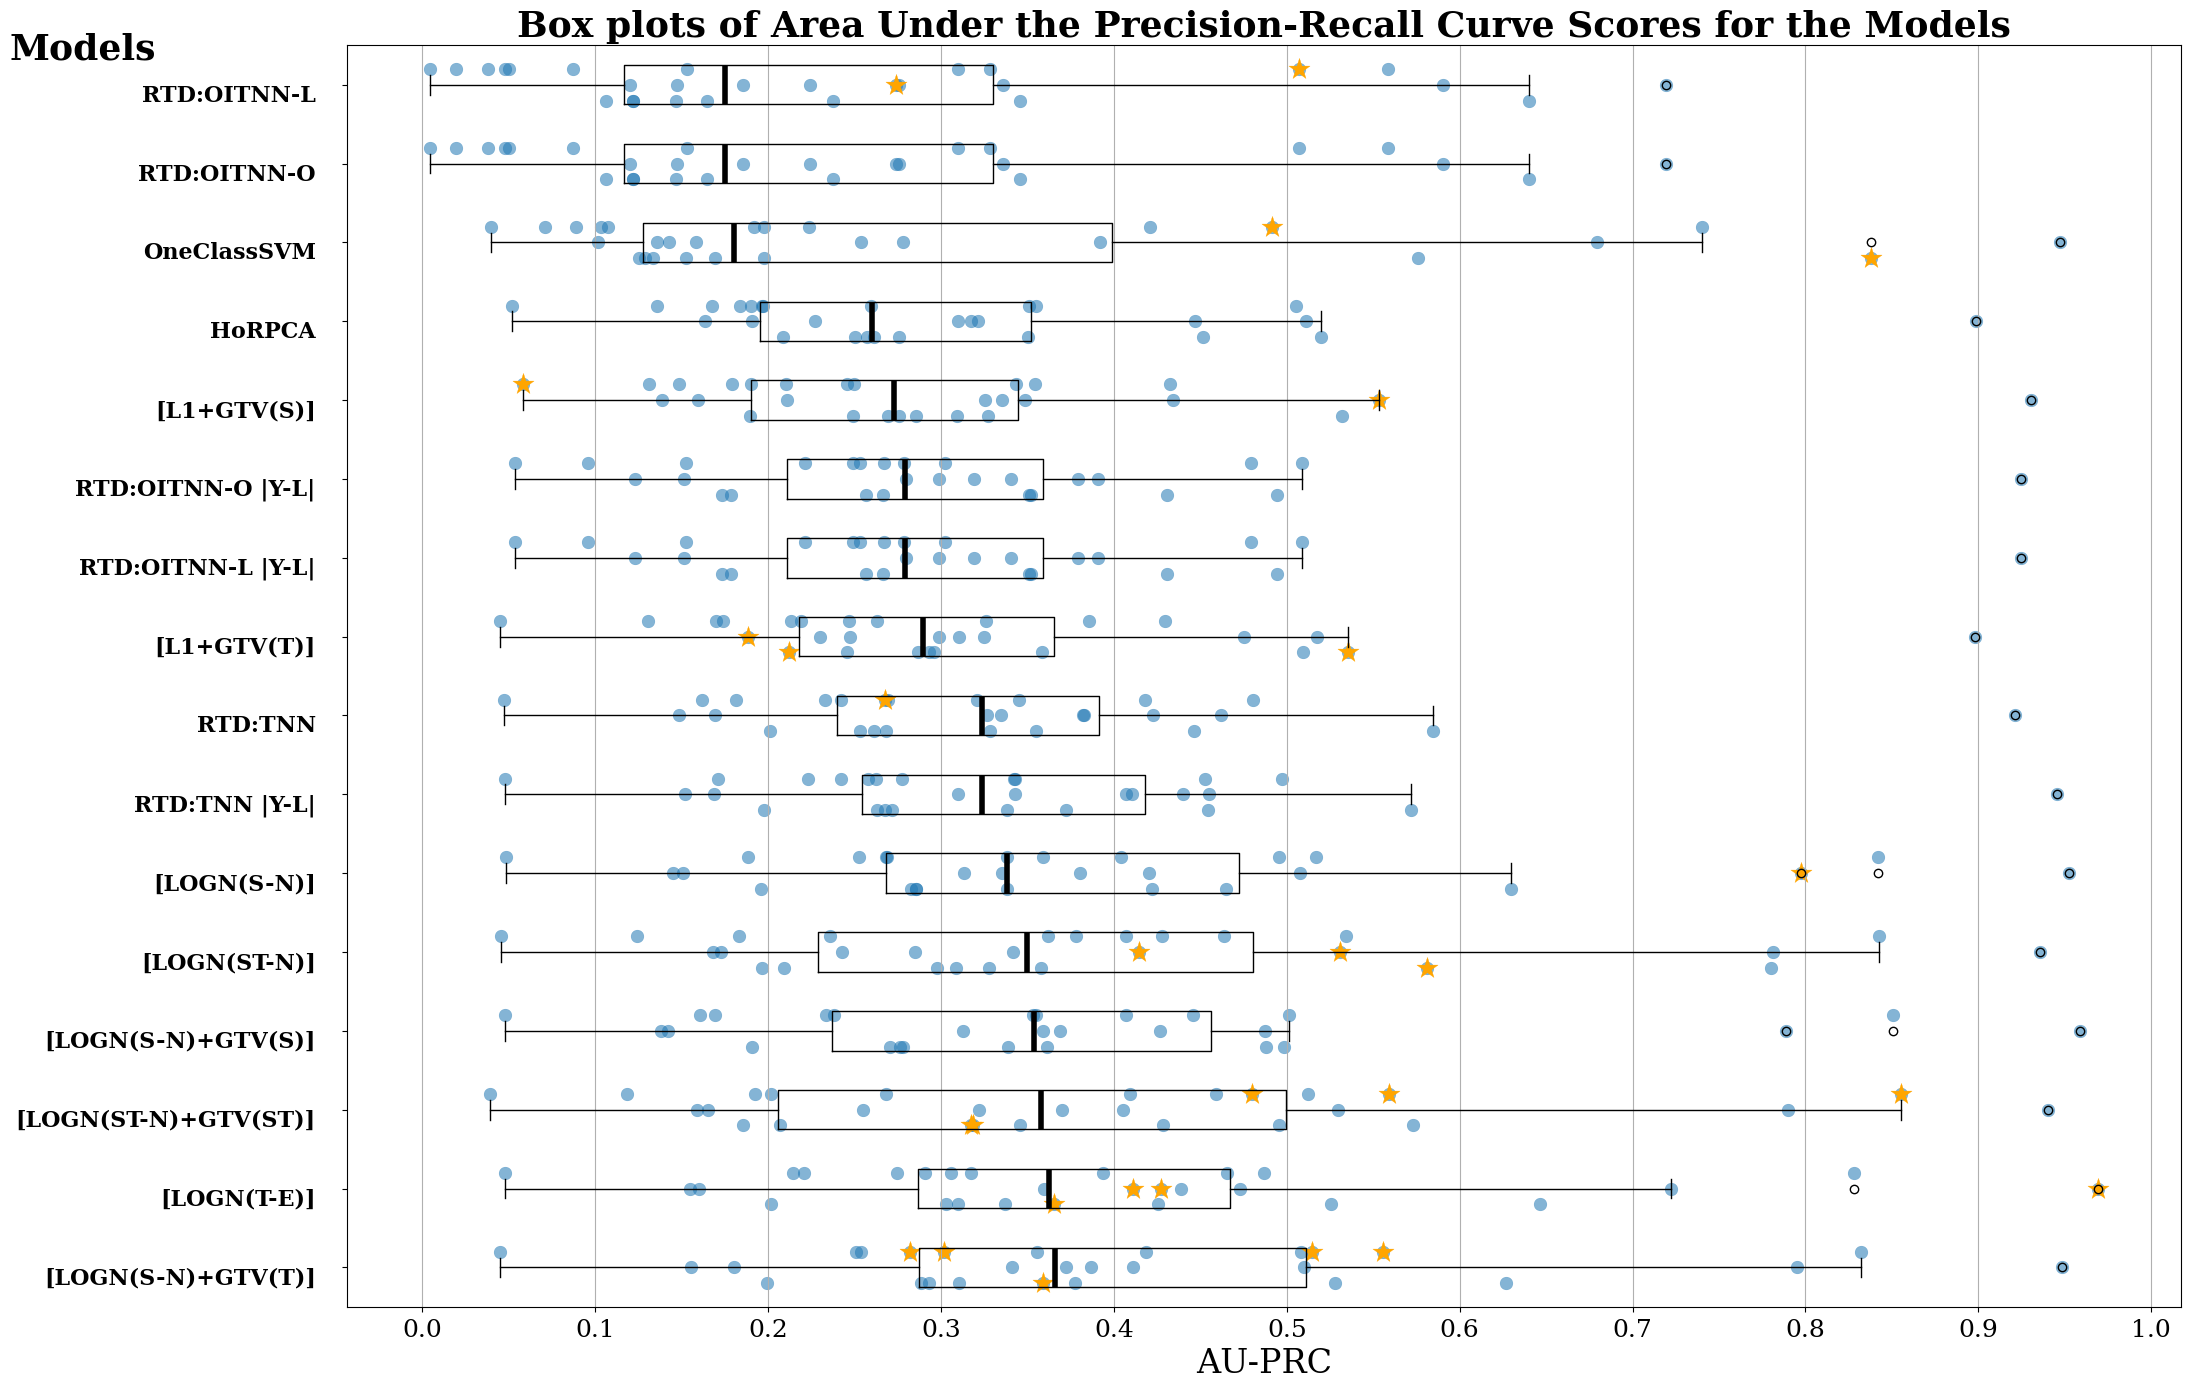

In [61]:

machine_ids = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 4},
               'orientation':'horizontal',
            }
# Model Performance Scatter Settings
alpha=0.55; s=85; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = s*3; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :26, 'fontweight': 'bold'} #'y': 1.01, 'x': -0.04}#,
# X Label Settings
y_ticks_settings = {'fontsize': 16, 'rotation': 0, 'ha': 'right', 'va': 'top', 'x': -0.01, 'fontweight': 'bold'}
y_label_settings = {'fontsize': 26, 'rotation': 0, 'ha': 'left', 'va': 'top', 'x':0.2, 'y': 1.01, 'fontweight': 'bold'}
x_label_settings = {'fontsize': 24, 'rotation': 'horizontal', 'y': 1.0, 'x':0.5, }#'fontweight': 'bold'}
x_ticks_settings = {'fontsize': 18}
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(22, 14))
if not isinstance(axes, np.ndarray):
    axes = [axes]

offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']


ys = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
ys = [item for sublist in ys for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in models]
ys_per_model = [np.array(ys) + m+1 for m in range(len(models))]
au_prc_list = [np.array(au_prcs[m]) for m in models]
au_roc_list = [np.array(au_rocs[m]) for m in models]
f1_list = [np.array(f1s[m]) for m in models]
pa_f1_list = [np.array(pa_f1s[m]) for m in models]
ys = [np.array(ys) + m for m in range(1, len(models)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
# axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[0].set_title('Box plots of Area Under the Precision-Recall Curve Scores for the Models',
                    **title_settings)
axes[0].scatter(au_prc_list, ys_per_model, marker=marker, s=s, alpha=alpha)
axes[0].boxplot(au_prc_list, **boxplot_cfg)

# axes[1].set_title('(b)',# 'F1 Scores of Different Models',
#                     **title_settings)
# axes[1].scatter(f1_list, ys_per_model, marker=marker, s=s, alpha=alpha)
# axes[1].boxplot(f1_list, **boxplot_cfg)

# axes[2].set_title('(c)', #'Point Adjusted F1 Scores of Different Models', 
#                   **title_settings)
# axes[2].scatter(xs_per_model, pa_f1_list, marker='o', s=s, alpha=alpha)
# axes[2].boxplot(pa_f1_list, **boxplot_cfg)
metrics = ['AU-PRC', 'F1', 'F1 (Point Adjusted)']



for i, ax in enumerate(axes):
    
    ax.xaxis.grid(True)
    ax.set_yticks([])
    # ax.set_yticks()
    xtick_locations = np.linspace(0, 1.0, 11)
    xtick_labels = [f'0.{i}' for i in range(0, 10)]+['1.0']
    # ax.set_yticklabels( ytick_labels, **y_ticks_settings)
    ax.set_xticks(xtick_locations, xtick_labels, **x_ticks_settings)
    ax.set_xlabel(metrics[i], **x_label_settings)

axes[0].set_yticks([y + 1 for y in range(len(model_names))],
                  labels=model_names,#[name.replace('[SNN]-', '') for name in model_names],
                  **y_ticks_settings)
axes[0].set_ylabel('Models', **y_label_settings);

# Scatter stars for models that had the best score for each channel

# best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
# best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
# best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
# best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(best_au_prc_models)):
    best_auprc_model = best_au_prc_models[ch]
    best_auprc_model_number = model_numbers[best_auprc_model]

    
    axes[0].scatter(best_au_prc_values.iloc[ch], ys[best_auprc_model_number][ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    # best_f1_model = best_f1_models[ch]
    # best_f1_model_number = model_numbers[best_f1_model]
    # axes[1].scatter(xs[best_f1_model_number][ch], best_f1_values.iloc[ch],
    #                 marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    # best_pa_f1_model = best_pa_f1_models[ch]
    # best_pa_f1_model_number = model_numbers[best_pa_f1_model]
    # axes[2].scatter(xs[best_pa_f1_model_number][ch], best_pa_f1_values.iloc[ch],
    #                 marker=best_marker, s=best_marker_size, color=best_marker_color)

fig.tight_layout()

/tmp/ipykernel_1966970/2870273570.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_auprc_model = best_au_prc_models[ch]


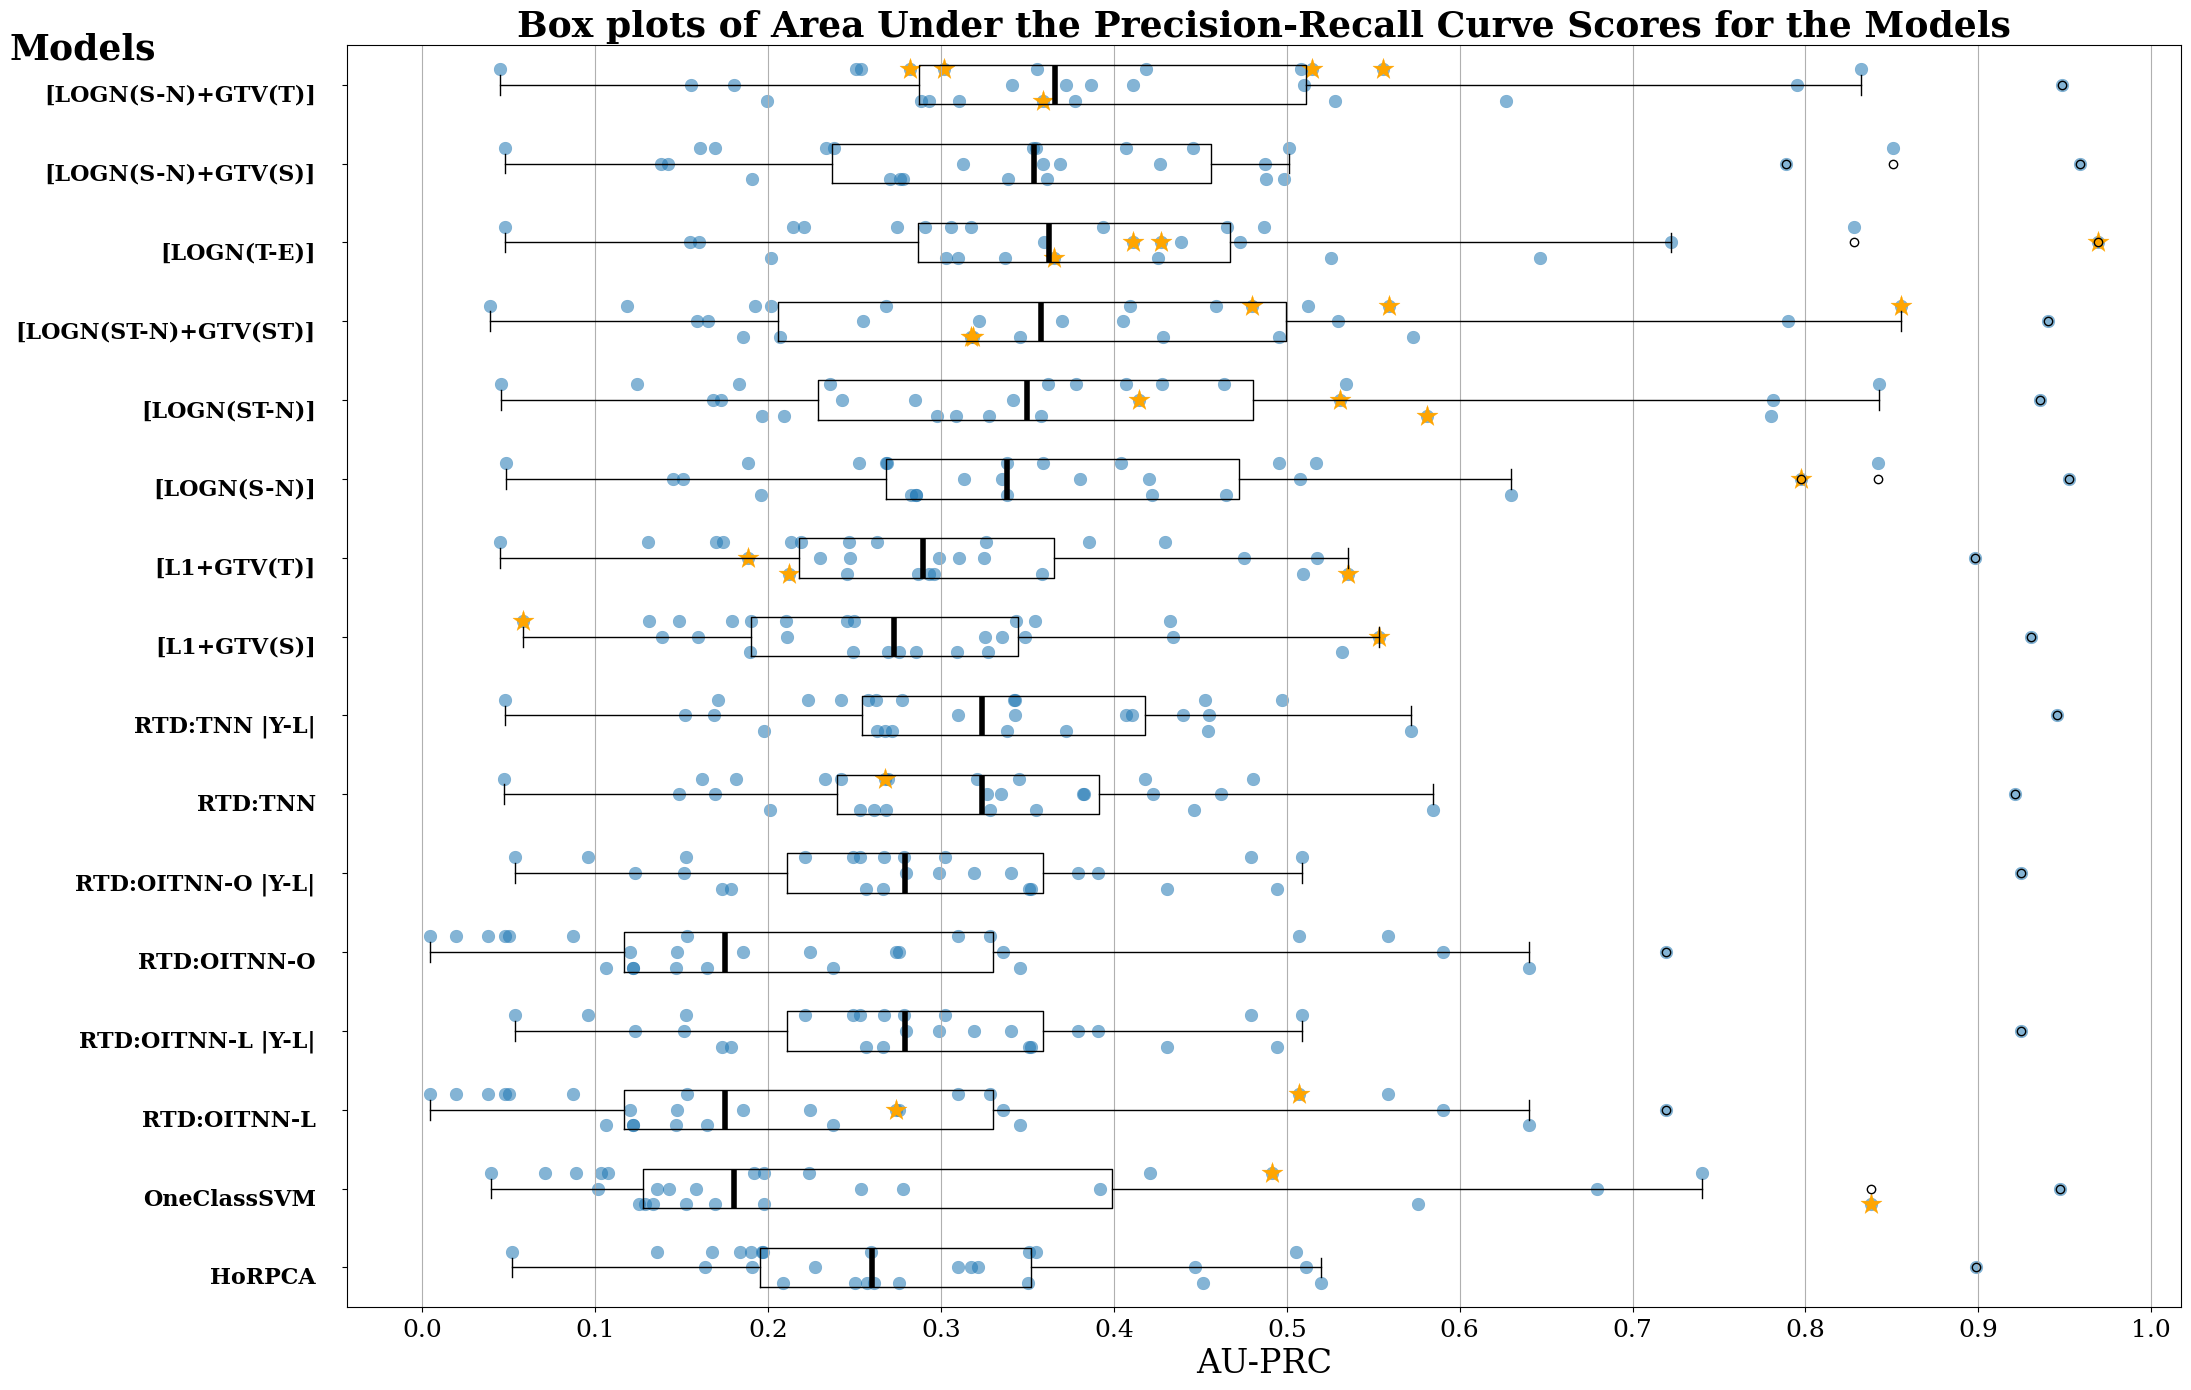

In [36]:
machine_ids = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 4},
               'orientation':'horizontal',
            }
# Model Performance Scatter Settings
alpha=0.55; s=85; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = s*3; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :26, 'fontweight': 'bold'} #'y': 1.01, 'x': -0.04}#,
# X Label Settings
y_ticks_settings = {'fontsize': 16, 'rotation': 0, 'ha': 'right', 'va': 'top', 'x': -0.01, 'fontweight': 'bold'}
y_label_settings = {'fontsize': 26, 'rotation': 0, 'ha': 'left', 'va': 'top', 'x':0.2, 'y': 1.01, 'fontweight': 'bold'}
x_label_settings = {'fontsize': 24, 'rotation': 'horizontal', 'y': 1.0, 'x':0.5, }#'fontweight': 'bold'}
x_ticks_settings = {'fontsize': 18}
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(22, 14))
if not isinstance(axes, np.ndarray):
    axes = [axes]

offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']


ys = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
ys = [item for sublist in ys for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in models]
ys_per_model = [np.array(ys) + m+1 for m in range(len(models))]
au_prc_list = [np.array(au_prcs[m]) for m in models]
au_roc_list = [np.array(au_rocs[m]) for m in models]
f1_list = [np.array(f1s[m]) for m in models]
pa_f1_list = [np.array(pa_f1s[m]) for m in models]
ys = [np.array(ys) + m for m in range(1, len(models)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
# axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[0].set_title('Box plots of Area Under the Precision-Recall Curve Scores for the Models',
                    **title_settings)
axes[0].scatter(au_prc_list, ys_per_model, marker=marker, s=s, alpha=alpha)
axes[0].boxplot(au_prc_list, **boxplot_cfg)

# axes[1].set_title('(b)',# 'F1 Scores of Different Models',
#                     **title_settings)
# axes[1].scatter(f1_list, ys_per_model, marker=marker, s=s, alpha=alpha)
# axes[1].boxplot(f1_list, **boxplot_cfg)

# axes[2].set_title('(c)', #'Point Adjusted F1 Scores of Different Models', 
#                   **title_settings)
# axes[2].scatter(xs_per_model, pa_f1_list, marker='o', s=s, alpha=alpha)
# axes[2].boxplot(pa_f1_list, **boxplot_cfg)
metrics = ['AU-PRC', 'F1', 'F1 (Point Adjusted)']



for i, ax in enumerate(axes):
    
    ax.xaxis.grid(True)
    ax.set_yticks([])
    # ax.set_yticks()
    xtick_locations = np.linspace(0, 1.0, 11)
    xtick_labels = [f'0.{i}' for i in range(0, 10)]+['1.0']
    # ax.set_yticklabels( ytick_labels, **y_ticks_settings)
    ax.set_xticks(xtick_locations, xtick_labels, **x_ticks_settings)
    ax.set_xlabel(metrics[i], **x_label_settings)

axes[0].set_yticks([y + 1 for y in range(len(model_names))],
                  labels=model_names,#[name.replace('[SNN]-', '') for name in model_names],
                  **y_ticks_settings)
axes[0].set_ylabel('Models', **y_label_settings);

# Scatter stars for models that had the best score for each channel

# best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
# best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
# best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
# best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(best_au_prc_models)):
    best_auprc_model = best_au_prc_models[ch]
    best_auprc_model_number = model_numbers[best_auprc_model]

    
    axes[0].scatter(best_au_prc_values.iloc[ch], ys[best_auprc_model_number][ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    # best_f1_model = best_f1_models[ch]
    # best_f1_model_number = model_numbers[best_f1_model]
    # axes[1].scatter(xs[best_f1_model_number][ch], best_f1_values.iloc[ch],
    #                 marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    # best_pa_f1_model = best_pa_f1_models[ch]
    # best_pa_f1_model_number = model_numbers[best_pa_f1_model]
    # axes[2].scatter(xs[best_pa_f1_model_number][ch], best_pa_f1_values.iloc[ch],
    #                 marker=best_marker, s=best_marker_size, color=best_marker_color)

fig.tight_layout()

/tmp/ipykernel_804930/2677399001.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_auprc_model = best_au_prc_models[ch]
/tmp/ipykernel_804930/2677399001.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_f1_model = best_f1_models[ch]
/tmp/ipykernel_804930/2677399001.py:92: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_pa_f1_model = best_pa_f1_models[ch]


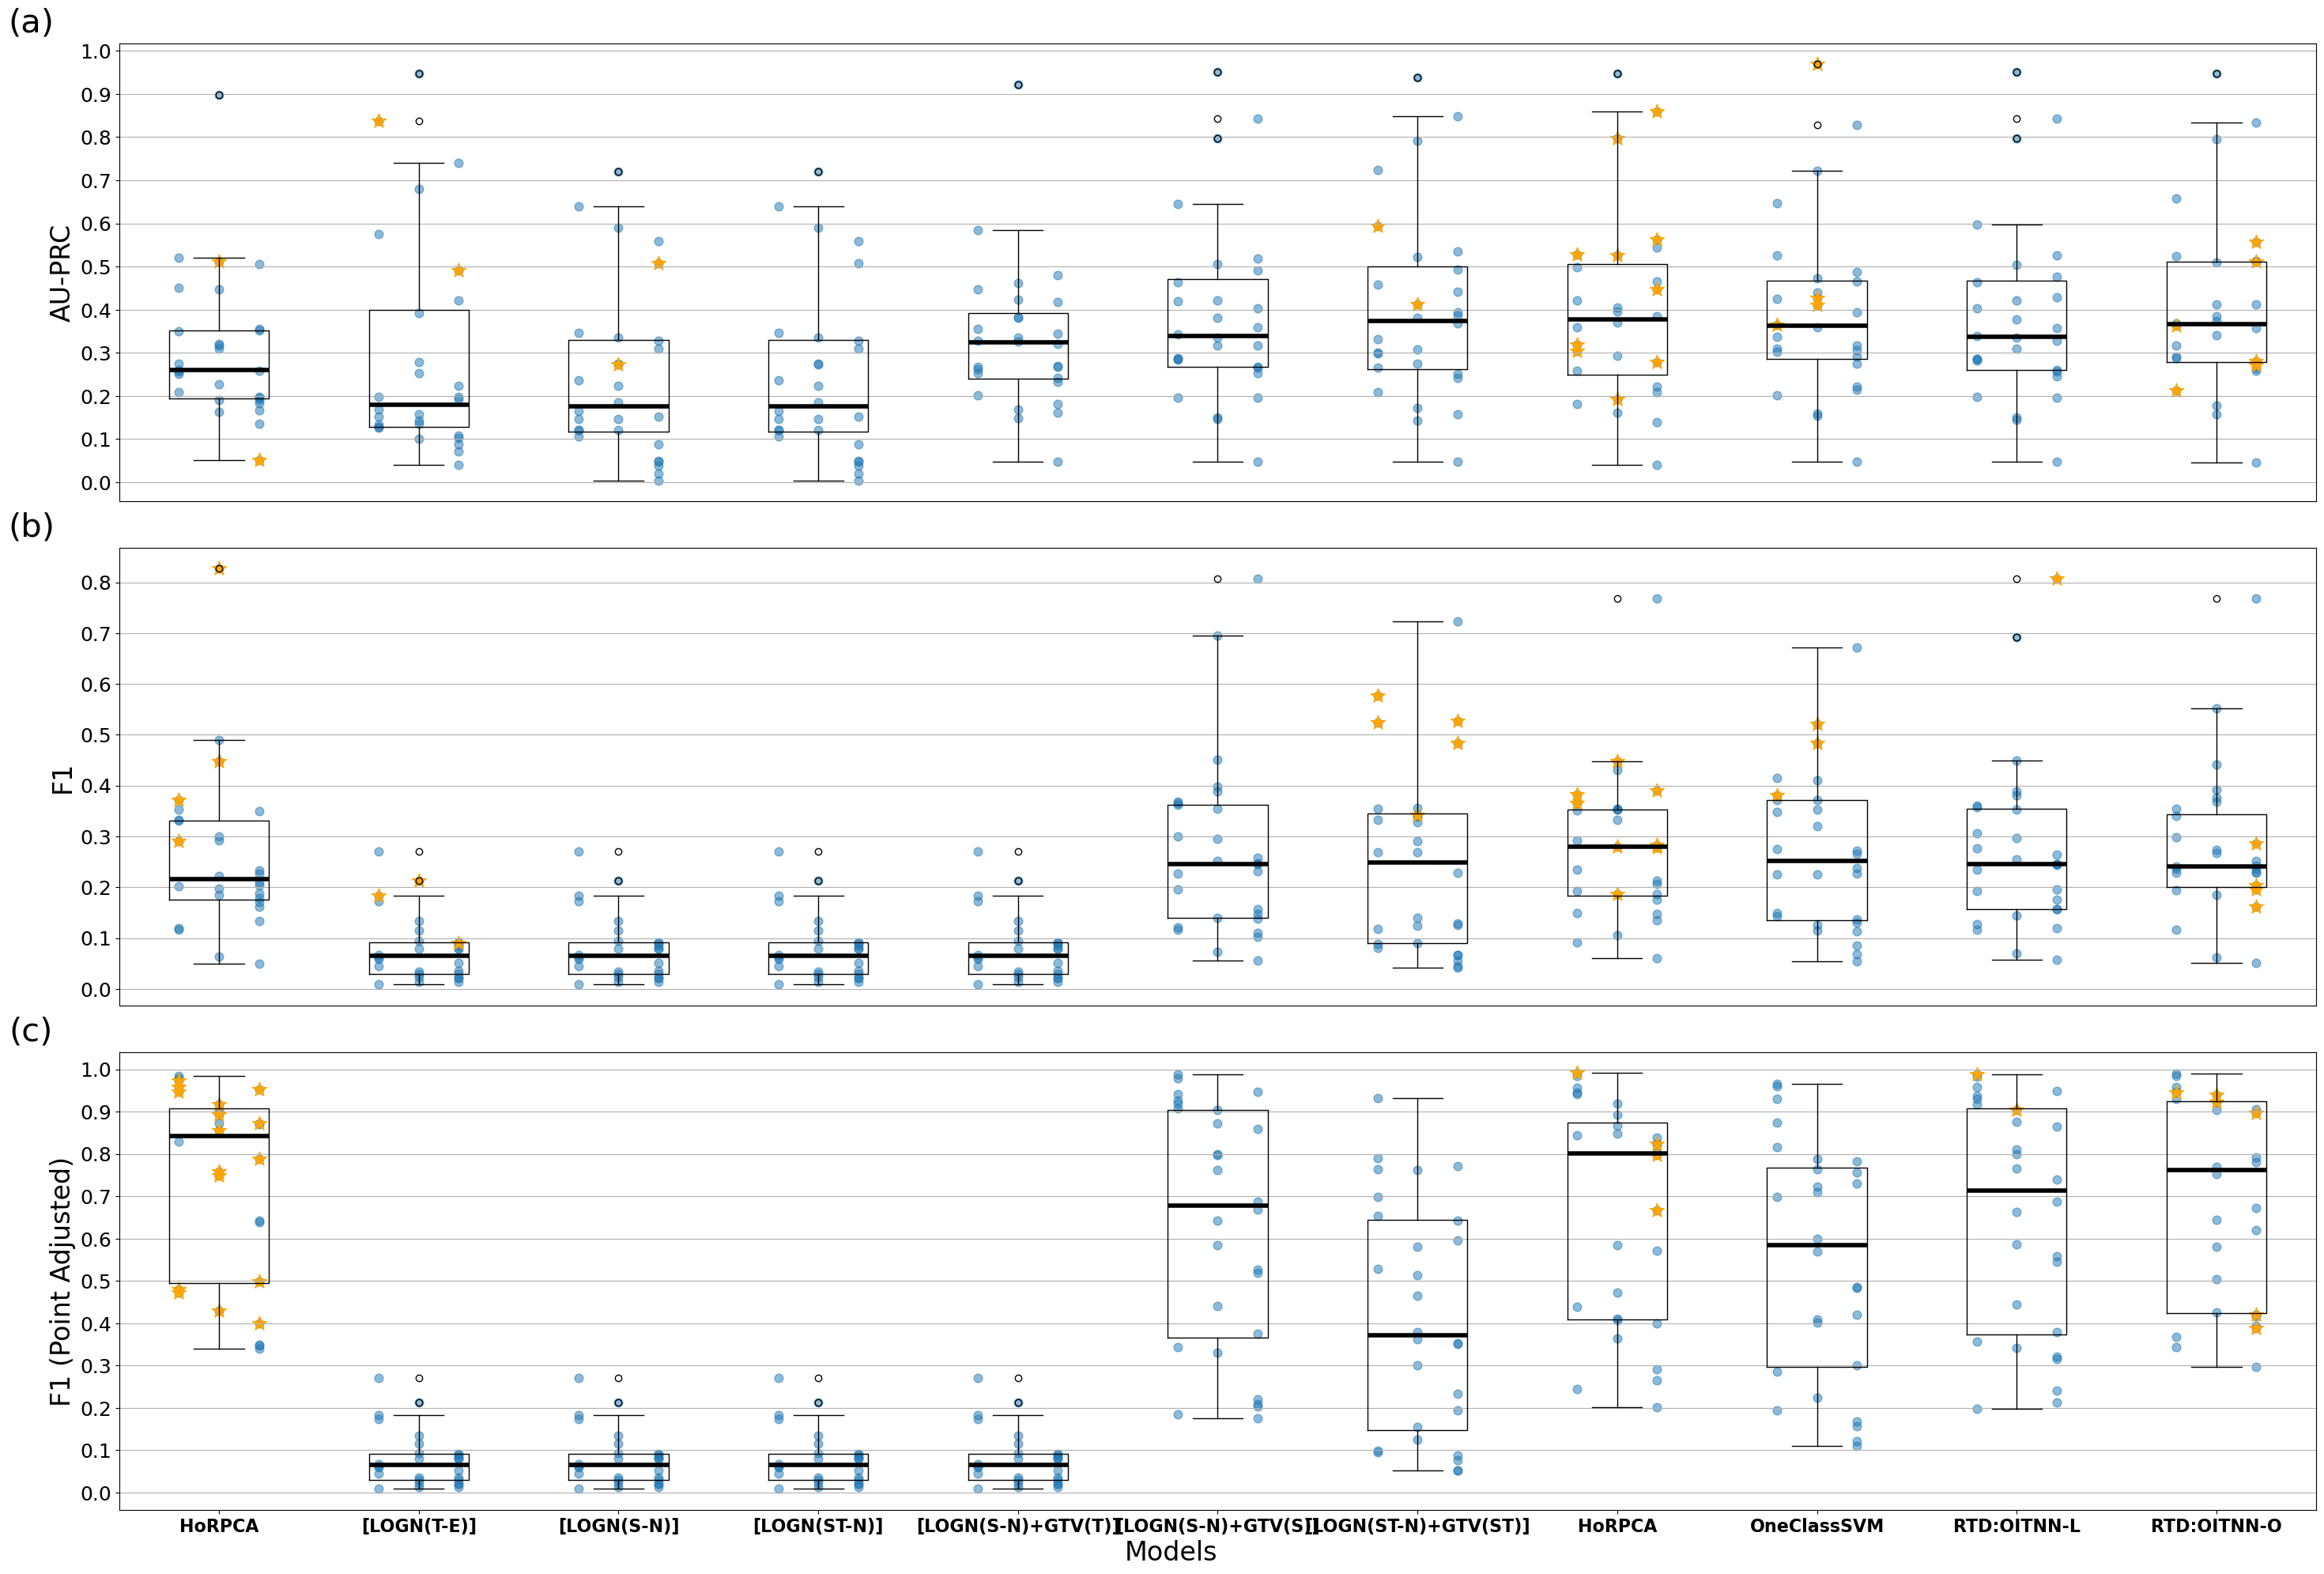

In [13]:
machine_ids = [1, 2, 3]
num_channels = {1:8, 2: 9, 3: 11}
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 4},
            }
# Model Performance Scatter Settings
alpha=0.50; s=60; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = s*3; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :30, 'y': 1.01, 'x': -0.04}#, 'fontweight': 'bold'}
# X Label Settings
x_ticks_settings = {'fontsize': 16, 'rotation': 0, 'ha': 'center', 'va': 'top', 'y': 0, 'fontweight': 'bold'}
x_label_settings = {'fontsize': 24, 'rotation': 0, 'ha': 'right', 'va': 'top', 'y': -0.3, }#'fontweight': 'bold'}
y_label_settings = {'fontsize': 24, 'rotation': 'vertical', 'y': 0.5, 'x':-0.2, }#'fontweight': 'bold'}
y_ticks_settings = {'fontsize': 18}
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(29, 20))
offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']


xs = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
xs = [item for sublist in xs for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in models]
xs_per_model = [np.array(xs) + m+1 for m in range(len(models))]
au_prc_list = [np.array(au_prcs[m]) for m in models]
au_roc_list = [np.array(au_rocs[m]) for m in models]
f1_list = [np.array(f1s[m]) for m in models]
pa_f1_list = [np.array(pa_f1s[m]) for m in models]
xs = [np.array(xs) + m for m in range(1, len(models)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
# axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[0].set_title('(a)',#'Area Under the Precision-Recall Curve Scores of Different Models',
                    **title_settings)
axes[0].scatter(xs_per_model, au_prc_list, marker=marker, s=s, alpha=alpha)
axes[0].boxplot(au_prc_list, **boxplot_cfg)

axes[1].set_title('(b)',# 'F1 Scores of Different Models',
                    **title_settings)
axes[1].scatter(xs_per_model, f1_list, marker=marker, s=s, alpha=alpha)
axes[1].boxplot(f1_list, **boxplot_cfg)

axes[2].set_title('(c)', #'Point Adjusted F1 Scores of Different Models', 
                  **title_settings)
axes[2].scatter(xs_per_model, pa_f1_list, marker='o', s=s, alpha=alpha)
axes[2].boxplot(pa_f1_list, **boxplot_cfg)
metrics = ['AU-PRC', 'F1', 'F1 (Point Adjusted)']



for i, ax in enumerate(axes):
    ax.yaxis.grid(True)
    ax.set_xticks([])
    # ax.set_yticks()
    ytick_locations = np.linspace(0, 1.0, 11)
    ytick_labels = [f'0.{i}' for i in range(0, 10)]+['1.0']
    # ax.set_yticklabels( ytick_labels, **y_ticks_settings)
    ax.set_yticks(ytick_locations, ytick_labels, **y_ticks_settings)
    ax.set_ylabel(metrics[i], **y_label_settings)

axes[-1].set_xticks([y + 1 for y in range(len(model_names))],
                  labels=[name.replace('[SNN]-', '') for name in model_names],
                  **x_ticks_settings)
axes[-1].set_xlabel('Models', **x_label_settings);

# Scatter stars for models that had the best score for each channel

# best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
# best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
# best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
# best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(best_au_prc_models)):
    best_auprc_model = best_au_prc_models[ch]
    best_auprc_model_number = model_numbers[best_auprc_model]

    
    axes[0].scatter(xs[best_auprc_model_number][ch], best_au_prc_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    best_f1_model = best_f1_models[ch]
    best_f1_model_number = model_numbers[best_f1_model]
    axes[1].scatter(xs[best_f1_model_number][ch], best_f1_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    best_pa_f1_model = best_pa_f1_models[ch]
    best_pa_f1_model_number = model_numbers[best_pa_f1_model]
    axes[2].scatter(xs[best_pa_f1_model_number][ch], best_pa_f1_values.iloc[ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)

fig.tight_layout()

In [60]:
au_prcs = df_all.pivot_table(index='Machine_Channel', columns='Model', values='au_prc')
au_rocs = df_all.pivot_table(index='Machine_Channel', columns='Model', values='au_roc')
f1s = df_all.pivot_table(index='Machine_Channel', columns='Model', values='f1')
pa_f1s = df_all.pivot_table(index='Machine_Channel', columns='Model', values='PA_F1')

models = au_prcs.columns.tolist()
# model_numbers = {m: i for i, m in enumerate(models)}
# model_names = []
# for m in models:
#     if m in model_configs.keys():
#         model_names.append(model_configs[m]['name'].replace('[SNN]-', '').replace('_sn',''))
#     else:
#         model_names.append(m)

best_au_prc_models = au_prcs.idxmax(axis=1)
best_au_prc_values = au_prcs.max(axis=1)
best_au_roc_models = au_rocs.idxmax(axis=1)
best_au_roc_values = au_rocs.max(axis=1)
best_f1_models = f1s.idxmax(axis=1)
best_f1_values = f1s.max(axis=1)
best_pa_f1_models = pa_f1s.idxmax(axis=1)
best_pa_f1_values = pa_f1s.max(axis=1)

print("Best AU-PRC Scores")
print(f"{best_au_prc_models.value_counts()}")
print("Best AU-ROC Scores")
print(f"{best_au_roc_models.value_counts()}")
print("Best F1 Scores")
print(f"{best_f1_models.value_counts()}")
print("Best F1(PA) Scores")
print(f"{best_pa_f1_models.value_counts()}")

Best AU-PRC Scores
RTD_TNN              21
SNN_LOGNST_GTVST     10
RTD_OITNN_L           7
SNN_LOGN_SN_GTV_T     6
SNN_LOGNTE            4
OneClassSVM           3
HoRPCA                3
SNN_LOGNST            2
Name: count, dtype: int64
Best AU-ROC Scores
RTD_TNN              24
SNN_LOGNST            7
SNN_LOGNST_GTVST      7
SNN_LOGNTE            5
SNN_LOGN_SN_GTV_T     5
RTD_OITNN_L           4
HoRPCA                2
SNN_LOGN_SN_GTV_S     1
OneClassSVM           1
Name: count, dtype: int64
Best F1 Scores
RTD_OITNN_L          28
SNN_LOGNST_GTVST      8
SNN_LOGNST            5
HoRPCA                4
SNN_LOGN_SN_GTV_T     4
SNN_LOGNTE            3
OneClassSVM           3
SNN_LOGN_SN_GTV_S     1
Name: count, dtype: int64
Best F1(PA) Scores
RTD_OITNN_L          28
HoRPCA               16
SNN_LOGN_SN_GTV_T     6
SNN_LOGNST_GTVST      4
SNN_LOGN_SN_GTV_S     2
Name: count, dtype: int64


In [61]:
best_f1_models

Machine_Channel
(1, 1)           RTD_OITNN_L
(1, 2)           RTD_OITNN_L
(1, 3)           RTD_OITNN_L
(1, 4)           RTD_OITNN_L
(1, 5)           RTD_OITNN_L
(1, 6)           RTD_OITNN_L
(1, 7)           RTD_OITNN_L
(1, 8)           RTD_OITNN_L
(2, 1)           RTD_OITNN_L
(2, 2)           RTD_OITNN_L
(2, 3)           RTD_OITNN_L
(2, 4)           RTD_OITNN_L
(2, 5)           RTD_OITNN_L
(2, 6)           RTD_OITNN_L
(2, 7)           RTD_OITNN_L
(2, 8)           RTD_OITNN_L
(2, 9)           RTD_OITNN_L
(3, 1)           RTD_OITNN_L
(3, 2)           RTD_OITNN_L
(3, 3)           RTD_OITNN_L
(3, 4)           RTD_OITNN_L
(3, 5)           RTD_OITNN_L
(3, 6)           RTD_OITNN_L
(3, 7)           RTD_OITNN_L
(3, 8)           RTD_OITNN_L
(3, 9)           RTD_OITNN_L
(3, 10)          RTD_OITNN_L
(3, 11)          RTD_OITNN_L
(1, 1)            SNN_LOGNST
(1, 2)                HoRPCA
(1, 3)            SNN_LOGNTE
(1, 4)      SNN_LOGNST_GTVST
(1, 5)                HoRPCA
(1, 6)            SNN_LOGNS

# HSI Results

In [5]:
df_py_results = pd.read_csv(RESULTS_DIR / 'hsi_python_results_392026.csv', index_col=[0,1])
# df_results

au_prcs = df_py_results.pivot_table(index='Category_Image', columns='Model', values='au_prc')
au_rocs = df_py_results.pivot_table(index='Category_Image', columns='Model', values='au_roc')
models = au_prcs.columns.tolist()
au_rocs

Model,HoRPCA,SNN_L1_GTVS_sn,SNN_L1_GTV_T,SNN_LOGN,SNN_LOGNSE,SNN_LOGNSE_GTVS_GTVT,SNN_LOGNSTE,SNN_LOGNTE,SNN_LOGN_SN_GTV_S,SNN_LOGN_SN_GTV_T
Category_Image,,,,,,,,,,
"(0, 1)",0.770900,0.854670,0.731905,0.910680,0.903938,0.897066,0.903938,0.895869,0.907837,0.910460
"(0, 2)",0.873653,0.903363,0.863440,0.940125,0.946941,0.947970,0.946941,0.940954,0.946374,0.940311
"(0, 3)",0.920066,0.915961,0.910480,0.953863,0.948367,0.949131,0.948367,0.943299,0.958267,0.953969
"(0, 4)",0.899770,0.894997,0.890973,0.975865,0.954296,0.948100,0.954296,0.947656,0.965921,0.975310
"(1, 1)",0.964119,0.986175,0.965344,0.975643,0.984281,0.985092,0.984281,0.954727,0.977822,0.976005
"(1, 2)",0.928263,0.918161,0.923434,0.918002,0.927313,0.926260,0.927313,0.927128,0.917596,0.918733
"(1, 3)",0.991500,0.991654,0.991591,0.994603,0.992401,0.992810,0.992401,0.992410,0.995140,0.994822
"(1, 4)",0.816820,0.826695,0.859488,0.970175,0.936133,0.927800,0.936133,0.933719,0.963600,0.969739
"(2, 1)",0.988144,0.983426,0.987404,0.994254,0.994005,0.993405,0.994005,0.994407,0.994143,0.994329


In [3]:
ABUHyperSpectral.images_in_category

{'airport': 4, 'beach': 4, 'urban': 5}

In [ ]:

start_col = 30
categories = ['airport', 'beach', 'urban']
img_in_cagegory = {
    'airport':4,
    'beach':4,
    'urban':5,
}
for c, category in enumerate(categories):
    for im_idx in range(1, img_in_cagegory[category]+1):
        print(f"\n category {category}, Channel {im_idx}:")
        for m, model_key in enumerate(model_keys):
            # model_result, ocsvm_result = run_model_on_ch(model_key, machine_id, channel_id,
            #                                 use_post_ocsvm=True)
            model_result = run_model_on_ch(model_key, category, im_idx,
                                            use_post_ocsvm=False, k=3)
            
            results[model_key][(c, im_idx)] = model_result
            model_name = model_configs[model_key]['name'].replace('[SNN]-', '').replace('_sn','')
            print((f"Model: {model_name:<30}AU-ROC={model_result['au_roc']:>7.3f}\t"
                    f" AU-PRC={model_result['au_prc']:>7.3f}\t"
                    f" F1={model_result['f1']:>7.3f}\t Precision={model_result['precision']:>7.3f}\t Recall={model_result['recall']:>7.3f}\t"
                    #f" PA-F1={model_result['PA_F1']:>7.3f}\t PA-Precision={model_result['PA_precision']:>7.3f}\t PA-Recall={model_result['PA_recall']:>7.3f}"
                  ))

# for model_key in results.keys():
#     for index in results[model_key].keys():
#         results[model_key][index].pop('st_scores', None)
#         results[model_key][index].pop('t_scores', None)

df_matlab_results = pd.DataFrame.from_dict({(i,j): results[i][j] 
                           for i in results.keys() 
                           for j in results[i].keys()},
                       orient='index')
df_matlab_results.index.names = ['Model', 'Category_Image']
df_matlab_results.to_csv('./results/hsi_python_results_392026.csv')
df_matlab_results

In [2]:
res = sp.io.loadmat('./results/hsi_matlab_alg_results_v2.mat')

In [3]:
res.keys()

dict_keys(['__header__', '__version__', '__globals__', 'model_keys', 'RTD_TNN', 'TRPCA', 'RTD_OITNN_O', 'RTD_OITNN_L'])

In [4]:
res = sp.io.loadmat('./results/hsi_matlab_alg_results_v2.mat')
keys = res['model_keys']
model_keys = [str(keys[0,i][0]) for i in range(len(keys[0]))]
# model_keys = ['RTD_TNN', 'TRPCA', /'RTD_OITNN_O', 'RTD_OITNN_L',
model_names = []
for k in model_keys:
    model_names.append(str(res[k]['name'][0,0][0]))
    model_names.append(str(res[k]['name'][0,0][0]) + " |Y-L|")

results = defaultdict(dict)
for key in model_keys:
    for cidx, cat in enumerate(ABUHyperSpectral.images_in_category.keys()):
        for im_id in range(1, ABUHyperSpectral.images_in_category[cat]+1):
        
            abu = ABUHyperSpectral(cat, im_id)

            Shat = res[key][0,0][cat][0,0][f'im_{im_id}'][0,0]['Shat']
            scores = np.sum((Shat**2), axis=2)**0.5
            t_labels = np.abs(scores) >0
            

            scoring_score = abu.anomaly_scoring_score(scores)
            detection_score = abu.anomaly_detection_score(t_labels)
            scoring_score.pop('st_scores', None)
            scoring_score.pop('t_scores', None)
            model_result = {**scoring_score, **detection_score}

            results[key][(cidx, im_id)] = model_result
            model_name = str(res[key]['name'][0,0][0])

            print((f"Model: {model_name:<30}AU-ROC={model_result['au_roc']:>7.3f}\t"
                    f" AU-PRC={model_result['au_prc']:>7.3f}\t"
            #         f" F1={model_result['f1']:>7.3f}\t"
            #         f" Precision={model_result['precision']:>7.3f}\t"
            #         f" Recall={model_result['recall']:>7.3f}\t"
            #         f" PA-F1={model_result['PA_F1']:>7.3f}\t"
            #         f" PA-Precision={model_result['PA_precision']:>7.3f}\t"
                    # f" PA-Recall={model_result['PA_recall']:>7.3f}"
                    ))
            
            Lhat = res[key][0,0][cat][0,0][f'im_{im_id}'][0,0]['Lhat'][0,0]
            scores_l = np.sum(((abu.Y - Lhat)**2), axis=2)**0.5
            t_labels = np.abs(scores_l) >0
            

            scoring_score_l = abu.anomaly_scoring_score(scores_l)
            detection_score_l = abu.anomaly_detection_score(t_labels)
            scoring_score_l.pop('st_scores', None)
            scoring_score_l.pop('t_scores', None)
            model_result_l = {**scoring_score_l, **detection_score_l}

            results[key + "_|Y-L|"][(cidx, im_id)] = model_result_l
            model_name = str(res[key]['name'][0,0][0]) + "_|Y-L|"
                          
            print((f"Model: {model_name:<30}AU-ROC={model_result_l['au_roc']:>7.3f}\t"
                    f" AU-PRC={model_result_l['au_prc']:>7.3f}\t"
                    ))

import pandas as pd
for model_key in results.keys():
    for index in results[model_key].keys():
        results[model_key][index].pop('st_scores', None)
        results[model_key][index].pop('t_scores', None)

df_matlab_results = pd.DataFrame.from_dict({(i,j): results[i][j] 
                           for i in results.keys() 
                           for j in results[i].keys()},
                       orient='index')
df_matlab_results.index.names = ['Model', 'Category_Image']
df_matlab_results

Model: RTD:OITNN-O                   AU-ROC=  0.694	 AU-PRC=  0.042	
Model: RTD:OITNN-O_|Y-L|             AU-ROC=  0.660	 AU-PRC=  0.040	
Model: RTD:OITNN-O                   AU-ROC=  0.676	 AU-PRC=  0.044	
Model: RTD:OITNN-O_|Y-L|             AU-ROC=  0.723	 AU-PRC=  0.041	
Model: RTD:OITNN-O                   AU-ROC=  0.921	 AU-PRC=  0.234	
Model: RTD:OITNN-O_|Y-L|             AU-ROC=  0.922	 AU-PRC=  0.234	
Model: RTD:OITNN-O                   AU-ROC=  0.551	 AU-PRC=  0.006	
Model: RTD:OITNN-O_|Y-L|             AU-ROC=  0.703	 AU-PRC=  0.009	
Model: RTD:OITNN-O                   AU-ROC=  0.951	 AU-PRC=  0.012	
Model: RTD:OITNN-O_|Y-L|             AU-ROC=  0.908	 AU-PRC=  0.011	
Model: RTD:OITNN-O                   AU-ROC=  0.904	 AU-PRC=  0.091	
Model: RTD:OITNN-O_|Y-L|             AU-ROC=  0.095	 AU-PRC=  0.011	
Model: RTD:OITNN-O                   AU-ROC=  0.928	 AU-PRC=  0.470	
Model: RTD:OITNN-O_|Y-L|             AU-ROC=  0.876	 AU-PRC=  0.462	
Model: RTD:OITNN-O                

au_prc    au_roc        f1  precision  recall
Model       Category_Image                                                 
RTD_OITNN_O (0, 1)          0.042295  0.694044  0.028391   0.014400     1.0
            (0, 2)          0.043935  0.676296  0.017250   0.008700     1.0
            (0, 3)          0.234190  0.921008  0.033432   0.017000     1.0
            (0, 4)          0.006259  0.550852  0.011928   0.006000     1.0
            (1, 1)          0.012255  0.951028  0.001687   0.000844     1.0
...                              ...       ...       ...        ...     ...
TRPCA_|Y-L| (2, 1)          0.518755  0.983884  0.013311   0.006700     1.0
            (2, 2)          0.949074  0.996841  0.030527   0.015500     1.0
            (2, 3)          0.014274  0.733691  0.010346   0.005200     1.0
            (2, 4)          0.924459  0.996384  0.052960   0.027200     1.0
            (2, 5)          0.355046  0.964540  0.045348   0.023200     1.0

[104 rows x 5 columns]

In [6]:
df_all = pd.concat([df_py_results,df_matlab_results])
df_all
df_all.to_csv('./results/hsi_ad_all_w_matlab.csv')

In [11]:
matlab_keys = [str(keys[0,i][0]) for i in range(len(keys[0]))]
matlab_keys = matlab_keys[2:]
matlab_names = {matlab_keys[i] : str(res[matlab_keys[i]]['name'][0,0][0])
               for i in range(len(matlab_keys))}
matlab_keys += ['RTD_TNN_|Y-L|', 'RTD_OITNN_O_|Y-L|', 'RTD_OITNN_L_|Y-L|', 'RTD_TNN_|Y-L|']
matlab_names['RTD_OITNN_O_|Y-L|'] = 'RTD:OITNN-O |Y-L|'
matlab_names['RTD_OITNN_L_|Y-L|'] = 'RTD:OITNN-L |Y-L|'
matlab_names['RTD_TNN_|Y-L|'] = 'RTD:TNN |Y-L|'
with open(CFG_DIR / 'model_configs.yaml') as f:
    model_configs = yaml.safe_load(f)

df_res = pd.read_csv('./results/hsi_ad_all_w_matlab.csv', index_col=[0,1])
au_prcs = df_res.pivot_table(index='Category_Image', columns='Model', values='au_prc')
au_rocs = df_res.pivot_table(index='Category_Image', columns='Model', values='au_roc')

# models = au_prcs.columns.tolist()
# mean_au_prcs = au_prcs.median(axis=0)
# models = mean_au_prcs.sort_values(axis=0, ascending=False).index.to_list()
mean_au_rocs = au_rocs.median(axis=0)
models = mean_au_rocs.sort_values(axis=0, ascending=False).index.to_list()
# mode_names = [model_names[m] for m in models]
model_numbers = {m: i for i, m in enumerate(models)}
model_names = []
for m in models:
    if m in model_configs.keys():
        model_names.append(model_configs[m]['name'].replace('[SNN]-', '').replace('_sn',''))
    elif m in matlab_names.keys():
        model_names.append(matlab_names[m])
    else:
        model_names.append(m)
best_au_prc_models = au_prcs.idxmax(axis=1)
best_au_prc_values = au_prcs.max(axis=1)
best_au_roc_models = au_rocs.idxmax(axis=1)
best_au_roc_values = au_rocs.max(axis=1)

print("Best AU-PRC Scores")
print(f"{best_au_prc_models.value_counts(dropna=False)}")
print("Best AU-ROC Scores")
print(f"{best_au_roc_models.value_counts()}")



Best AU-PRC Scores
SNN_L1_GTVS_sn          3
SNN_LOGN                2
HoRPCA                  2
SNN_LOGNSE              2
TRPCA                   1
SNN_LOGN_SN_GTV_S       1
SNN_LOGNSE_GTVS_GTVT    1
RTD_OITNN_O             1
Name: count, dtype: int64
Best AU-ROC Scores
SNN_LOGN                4
SNN_LOGNSE_GTVS_GTVT    2
SNN_LOGN_SN_GTV_S       2
SNN_L1_GTVS_sn          1
HoRPCA                  1
SNN_LOGNTE              1
RTD_OITNN_O             1
SNN_LOGNSE              1
Name: count, dtype: int64


In [ ]:
au_prcs.T

Category_Image,"(0, 1)","(0, 2)","(0, 3)","(0, 4)","(1, 1)","(1, 2)","(1, 3)","(1, 4)","(2, 1)","(2, 2)","(2, 3)","(2, 4)","(2, 5)"
Model,,,,,,,,,,,,,
HoRPCA,0.165899,0.249251,0.293194,0.077718,0.166142,0.147652,0.492202,0.395151,0.783266,0.880015,0.359875,0.566337,0.455146
RTD_OITNN_L,0.028873,0.050633,0.105736,0.038373,0.135293,0.036881,0.197249,0.004130,0.029205,0.269095,0.046775,0.407222,0.151846
RTD_OITNN_L_|Y-L|,0.039924,0.040738,0.234198,0.009101,0.010612,0.011103,0.462471,0.128793,0.517681,0.948943,0.012831,0.924458,0.355037
RTD_OITNN_O,0.042295,0.043935,0.234190,0.006259,0.012255,0.091338,0.470140,0.008146,0.522289,0.962294,0.028369,0.925390,0.354758
RTD_OITNN_O_|Y-L|,0.039924,0.040737,0.234202,0.009101,0.010612,0.011103,0.462471,0.146977,0.517681,0.948943,0.012829,0.924458,0.355037
RTD_TNN,0.047836,0.048657,0.250325,0.005860,0.012844,0.097368,0.525124,0.276708,0.557079,0.959711,0.036492,0.921425,0.373717
RTD_TNN_|Y-L|,0.043529,0.046215,0.237487,0.007008,0.011797,0.013169,0.470752,0.111641,0.523890,0.962697,0.035082,0.924814,0.354775
SNN_L1_GTVS_sn,0.181391,0.256515,0.302667,0.074188,0.174925,0.142807,0.466880,0.367600,0.788174,0.878961,0.357900,0.554483,0.434130
SNN_L1_GTV_T,0.161616,0.247503,0.290350,0.076997,0.166317,0.146517,0.492484,0.395233,0.783086,0.879404,0.359648,0.563360,0.453545


: 

In [15]:
au_rocs.T

Category_Image,"(0, 1)","(0, 2)","(0, 3)","(0, 4)","(1, 1)","(1, 2)","(1, 3)","(1, 4)","(2, 1)","(2, 2)","(2, 3)","(2, 4)","(2, 5)"
Model,,,,,,,,,,,,,
HoRPCA,0.770900,0.873653,0.920066,0.899770,0.964119,0.928263,0.991500,0.816820,0.988144,0.994788,0.971138,0.979254,0.966137
RTD_OITNN_L,0.662162,0.735318,0.638725,0.739757,0.979264,0.650358,0.855860,0.641561,0.740523,0.769231,0.724674,0.905734,0.814838
RTD_OITNN_L_|Y-L|,0.660067,0.722537,0.921661,0.703164,0.907648,0.095282,0.876273,0.905629,0.983029,0.996750,0.729670,0.996385,0.964542
RTD_OITNN_O,0.694044,0.676296,0.921008,0.550852,0.951028,0.904176,0.927557,0.699400,0.983321,0.999353,0.766263,0.996539,0.961996
RTD_OITNN_O_|Y-L|,0.660069,0.722530,0.921662,0.703159,0.907644,0.095282,0.876273,0.906144,0.983029,0.996750,0.729664,0.996385,0.964542
RTD_TNN,0.701604,0.681953,0.922196,0.520453,0.949944,0.911499,0.936849,0.887058,0.982172,0.999280,0.805753,0.996053,0.964125
RTD_TNN_|Y-L|,0.707107,0.701550,0.924096,0.601016,0.948628,0.194634,0.915161,0.903543,0.983758,0.999360,0.834212,0.996496,0.962668
SNN_L1_GTVS_sn,0.854670,0.903363,0.915961,0.894997,0.986175,0.918161,0.991654,0.826695,0.983426,0.994513,0.970765,0.960993,0.917646
SNN_L1_GTV_T,0.731905,0.863440,0.910480,0.890973,0.965344,0.923434,0.991591,0.859488,0.987404,0.994775,0.966151,0.978075,0.964371


/tmp/ipykernel_3071829/3091336948.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_auprc_model = best_au_prc_models[ch]


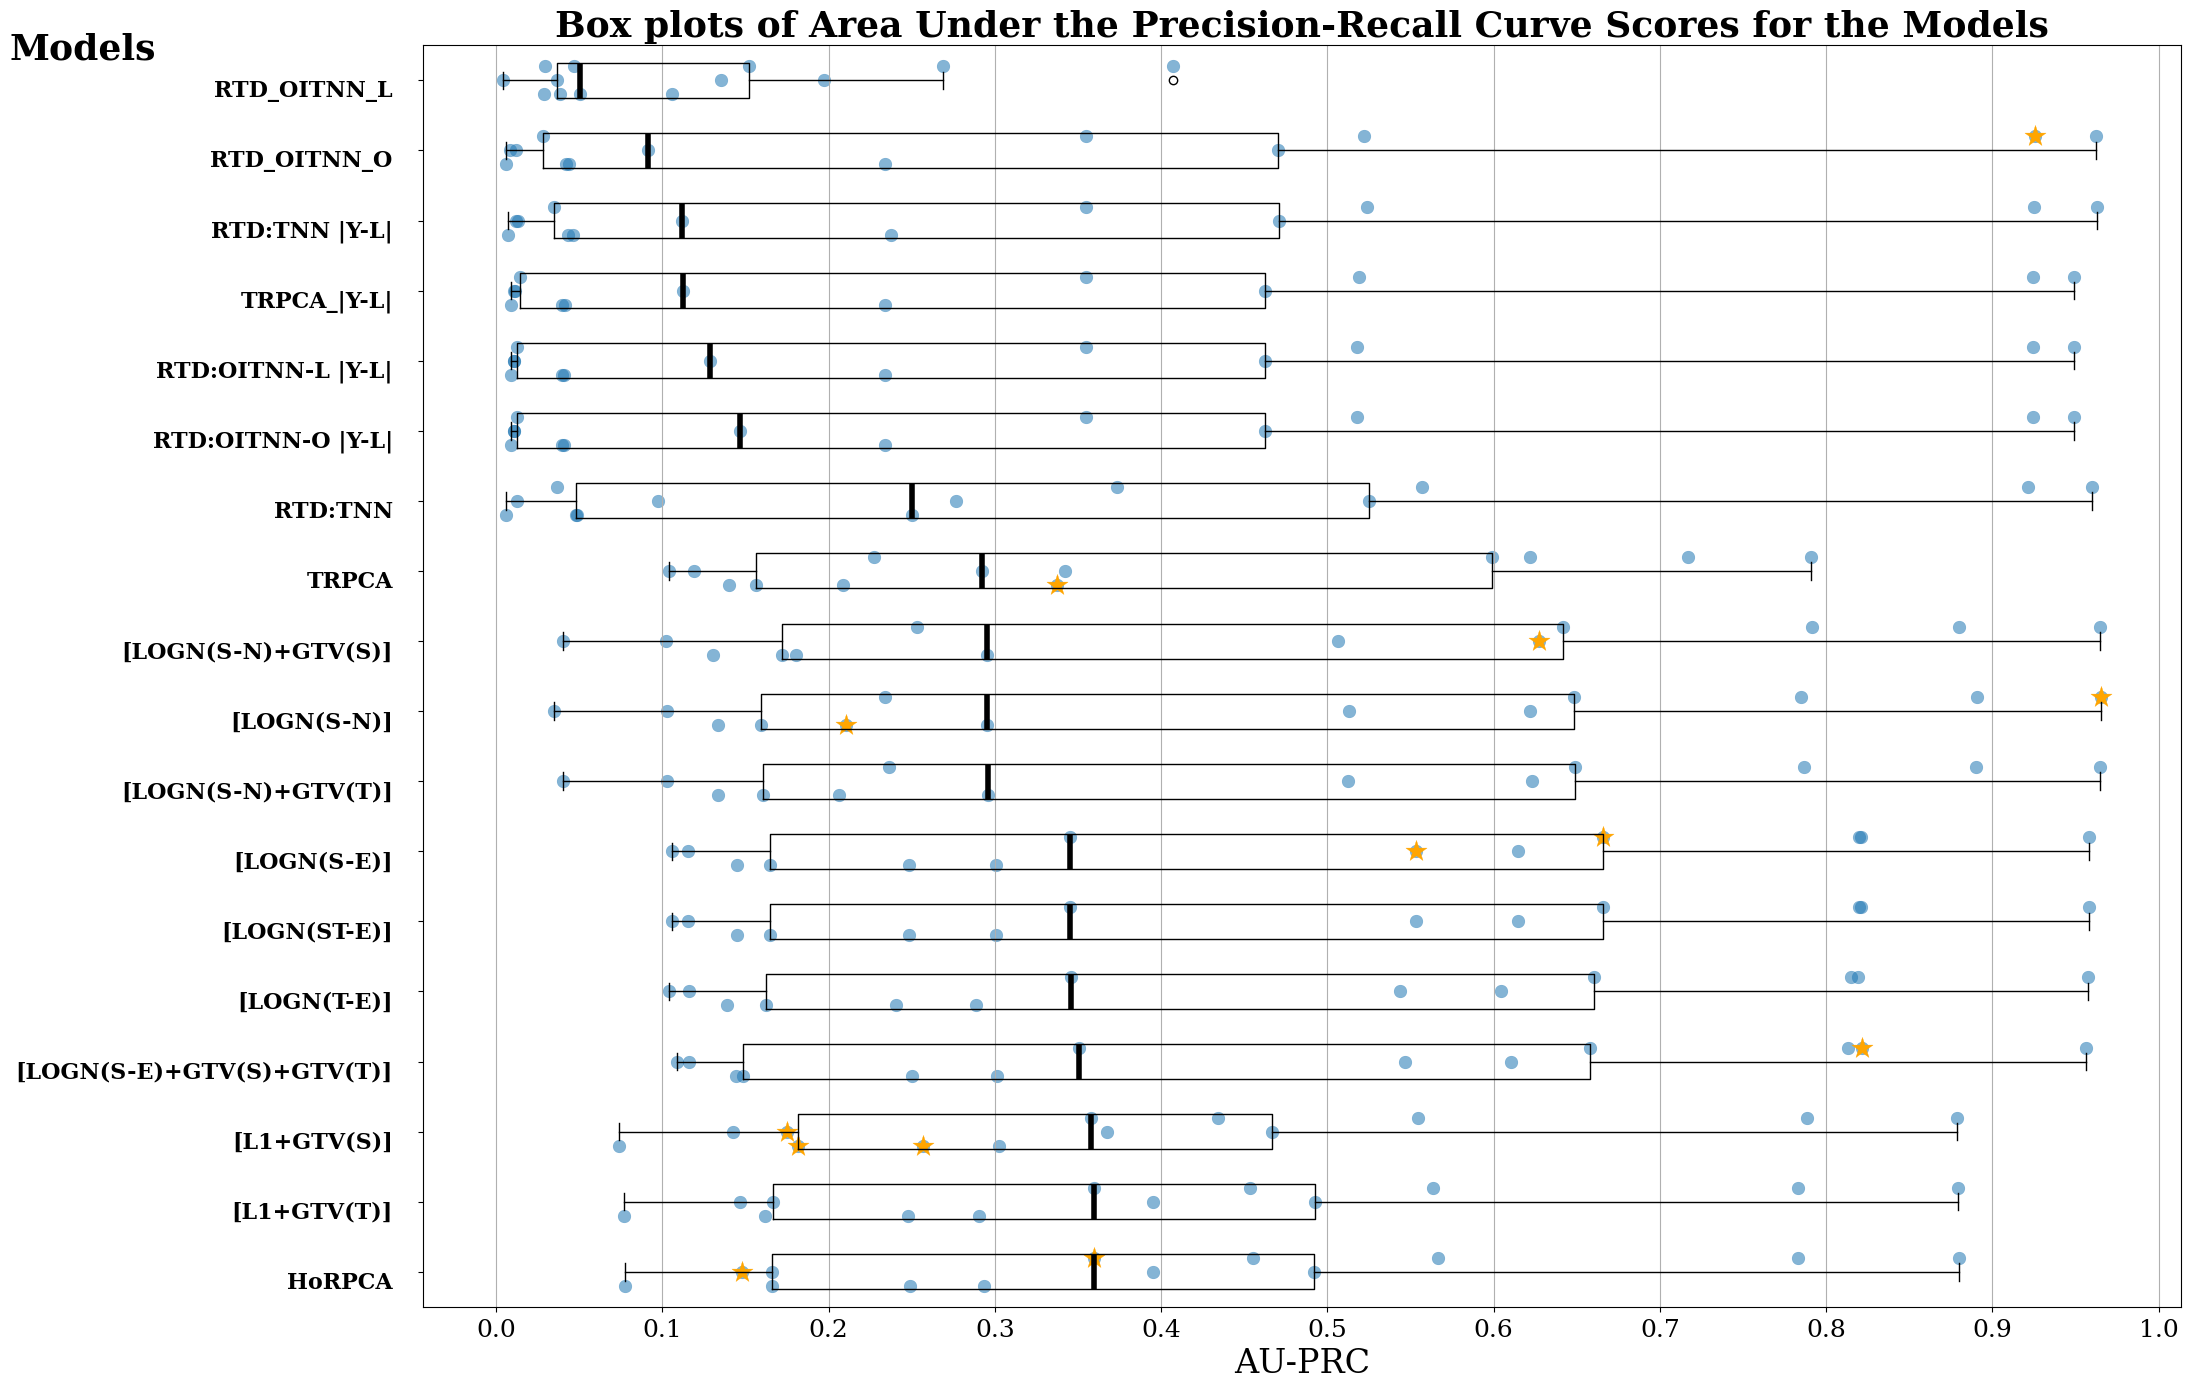

In [10]:
machine_ids = [1, 2, 3]
num_channels = {1:4, 2: 4, 3: 5}
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 4},
               'orientation':'horizontal',
            }
# Model Performance Scatter Settings
alpha=0.55; s=85; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = s*3; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :26, 'fontweight': 'bold'} #'y': 1.01, 'x': -0.04}#,
# X Label Settings
y_ticks_settings = {'fontsize': 16, 'rotation': 0, 'ha': 'right', 'va': 'top', 'x': -0.01, 'fontweight': 'bold'}
y_label_settings = {'fontsize': 26, 'rotation': 0, 'ha': 'left', 'va': 'top', 'x':0.2, 'y': 1.01, 'fontweight': 'bold'}
x_label_settings = {'fontsize': 24, 'rotation': 'horizontal', 'y': 1.0, 'x':0.5, }#'fontweight': 'bold'}
x_ticks_settings = {'fontsize': 18}
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(22, 14))
if not isinstance(axes, np.ndarray):
    axes = [axes]

offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']


ys = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
ys = [item for sublist in ys for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in models]
ys_per_model = [np.array(ys) + m+1 for m in range(len(models))]
au_prc_list = [np.array(au_prcs[m]) for m in models]
au_roc_list = [np.array(au_rocs[m]) for m in models]
ys = [np.array(ys) + m for m in range(1, len(models)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
# axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[0].set_title('Box plots of Area Under the Precision-Recall Curve Scores for the Models',
                    **title_settings)
axes[0].scatter(au_prc_list, ys_per_model, marker=marker, s=s, alpha=alpha)
axes[0].boxplot(au_prc_list, **boxplot_cfg)

# axes[1].set_title('(b)',# 'F1 Scores of Different Models',
#                     **title_settings)
# axes[1].scatter(f1_list, ys_per_model, marker=marker, s=s, alpha=alpha)
# axes[1].boxplot(f1_list, **boxplot_cfg)

# axes[2].set_title('(c)', #'Point Adjusted F1 Scores of Different Models', 
#                   **title_settings)
# axes[2].scatter(xs_per_model, pa_f1_list, marker='o', s=s, alpha=alpha)
# axes[2].boxplot(pa_f1_list, **boxplot_cfg)
metrics = ['AU-PRC', 'F1', 'F1 (Point Adjusted)']



for i, ax in enumerate(axes):
    
    ax.xaxis.grid(True)
    ax.set_yticks([])
    # ax.set_yticks()
    xtick_locations = np.linspace(0, 1.0, 11)
    xtick_labels = [f'0.{i}' for i in range(0, 10)]+['1.0']
    # ax.set_yticklabels( ytick_labels, **y_ticks_settings)
    ax.set_xticks(xtick_locations, xtick_labels, **x_ticks_settings)
    ax.set_xlabel(metrics[i], **x_label_settings)

axes[0].set_yticks([y + 1 for y in range(len(model_names))],
                  labels=model_names,#[name.replace('[SNN]-', '') for name in model_names],
                  **y_ticks_settings)
axes[0].set_ylabel('Models', **y_label_settings);

# Scatter stars for models that had the best score for each channel

# best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
# best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
# best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
# best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(best_au_prc_models)):
    best_auprc_model = best_au_prc_models[ch]
    best_auprc_model_number = model_numbers[best_auprc_model]

    
    axes[0].scatter(best_au_prc_values.iloc[ch], ys[best_auprc_model_number][ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    # best_f1_model = best_f1_models[ch]
    # best_f1_model_number = model_numbers[best_f1_model]
    # axes[1].scatter(xs[best_f1_model_number][ch], best_f1_values.iloc[ch],
    #                 marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    # best_pa_f1_model = best_pa_f1_models[ch]
    # best_pa_f1_model_number = model_numbers[best_pa_f1_model]
    # axes[2].scatter(xs[best_pa_f1_model_number][ch], best_pa_f1_values.iloc[ch],
    #                 marker=best_marker, s=best_marker_size, color=best_marker_color)

fig.tight_layout()

/tmp/ipykernel_3071829/2249921014.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_auprc_model = best_au_prc_models[ch]


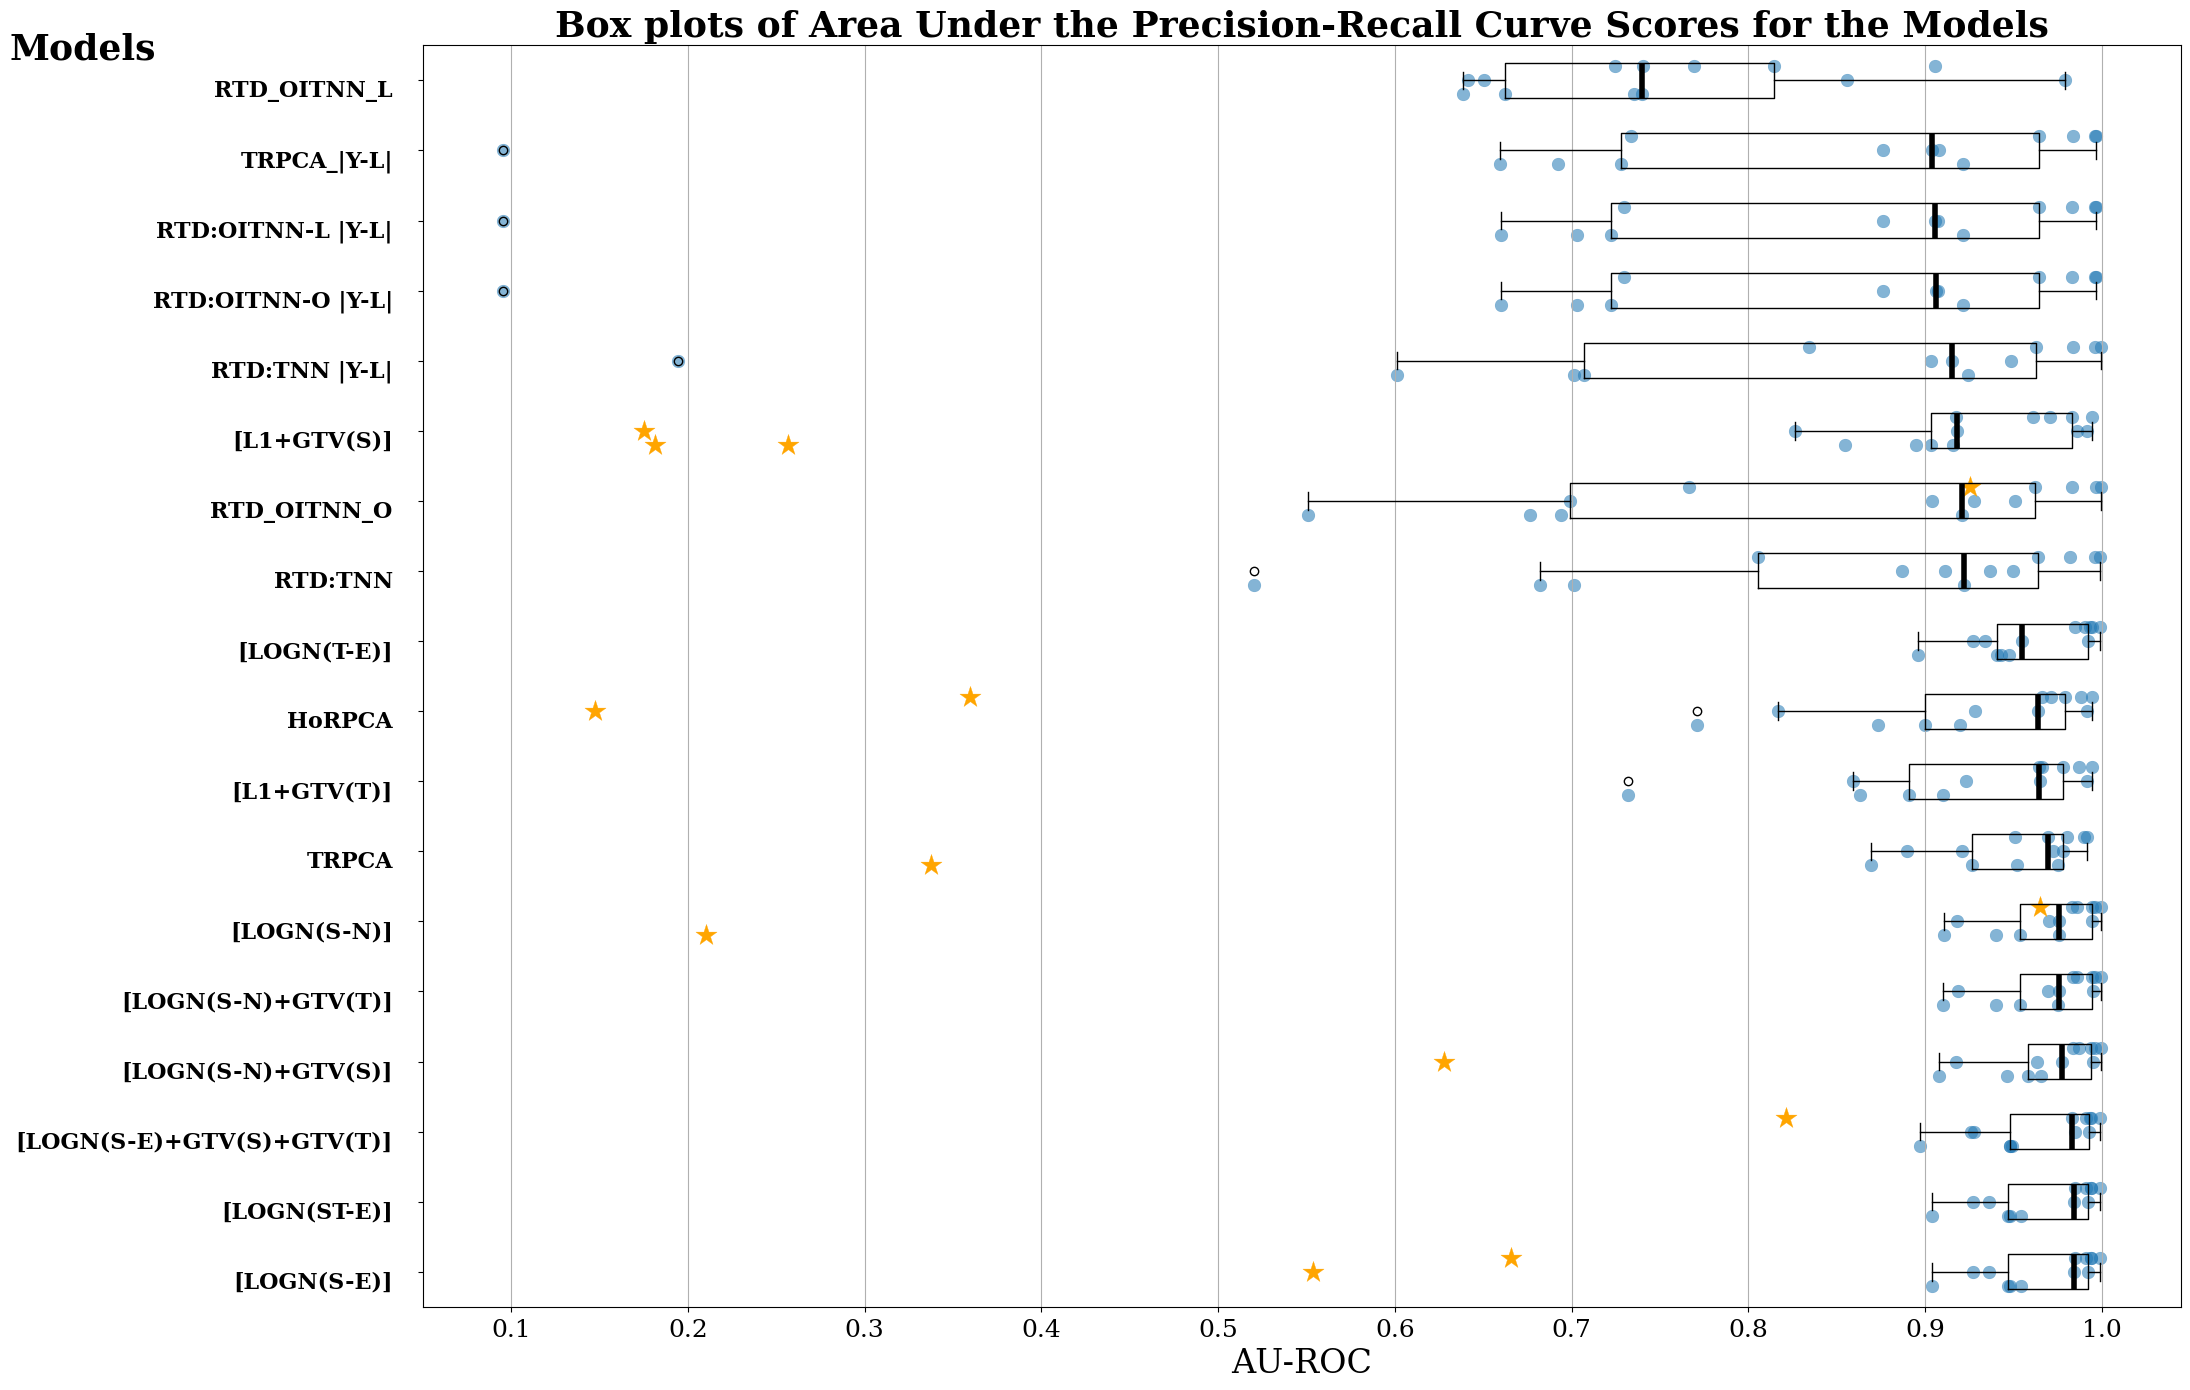

In [12]:
machine_ids = [1, 2, 3]
num_channels = {1:4, 2: 4, 3: 5}
# Boxplot Settings
boxplot_cfg = {'medianprops': {'color': 'black', 'linewidth': 4},
               'orientation':'horizontal',
            }
# Model Performance Scatter Settings
alpha=0.55; s=85; marker='o'
# Best Model Scatter Settings
best_marker = '*'; best_marker_size = s*3; best_marker_color = 'orange'
# Title Settings
title_settings = {'fontsize' :26, 'fontweight': 'bold'} #'y': 1.01, 'x': -0.04}#,
# X Label Settings
y_ticks_settings = {'fontsize': 16, 'rotation': 0, 'ha': 'right', 'va': 'top', 'x': -0.01, 'fontweight': 'bold'}
y_label_settings = {'fontsize': 26, 'rotation': 0, 'ha': 'left', 'va': 'top', 'x':0.2, 'y': 1.01, 'fontweight': 'bold'}
x_label_settings = {'fontsize': 24, 'rotation': 'horizontal', 'y': 1.0, 'x':0.5, }#'fontweight': 'bold'}
x_ticks_settings = {'fontsize': 18}
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(22, 14))
if not isinstance(axes, np.ndarray):
    axes = [axes]

offsets = [-0.2, 0, 0.2]
colors = ['blue', 'orange', 'green']


ys = [[offsets[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
ys = [item for sublist in ys for item in sublist]
clrs =[[colors[m-1]]*num_channels[m] for m in range(1, len(machine_ids) + 1)]
clrs = [item for sublist in clrs for item in sublist]
clrs_per_model = [clrs for m in models]
ys_per_model = [np.array(ys) + m+1 for m in range(len(models))]
au_prc_list = [np.array(au_prcs[m]) for m in models]
au_roc_list = [np.array(au_rocs[m]) for m in models]
ys = [np.array(ys) + m for m in range(1, len(models)+1)]
# markers =['o', 's', '^', 'D', 'x', 'v', '*']
# colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
# axes[0].scatter(xs_per_model, au_rocs, marker=marker, s=s, alpha=alpha)
# axes[0].set_ylim(0, 1.05)
axes[0].set_title('Box plots of Area Under the Precision-Recall Curve Scores for the Models',
                    **title_settings)
axes[0].scatter(au_roc_list, ys_per_model, marker=marker, s=s, alpha=alpha)
axes[0].boxplot(au_roc_list, **boxplot_cfg)

# axes[1].set_title('(b)',# 'F1 Scores of Different Models',
#                     **title_settings)
# axes[1].scatter(f1_list, ys_per_model, marker=marker, s=s, alpha=alpha)
# axes[1].boxplot(f1_list, **boxplot_cfg)

# axes[2].set_title('(c)', #'Point Adjusted F1 Scores of Different Models', 
#                   **title_settings)
# axes[2].scatter(xs_per_model, pa_f1_list, marker='o', s=s, alpha=alpha)
# axes[2].boxplot(pa_f1_list, **boxplot_cfg)
metrics = ['AU-ROC', 'F1', 'F1 (Point Adjusted)']



for i, ax in enumerate(axes):
    
    ax.xaxis.grid(True)
    ax.set_yticks([])
    # ax.set_yticks()
    xtick_locations = np.linspace(0, 1.0, 11)
    xtick_labels = [f'0.{i}' for i in range(0, 10)]+['1.0']
    # ax.set_yticklabels( ytick_labels, **y_ticks_settings)
    ax.set_xticks(xtick_locations, xtick_labels, **x_ticks_settings)
    ax.set_xlabel(metrics[i], **x_label_settings)

axes[0].set_yticks([y + 1 for y in range(len(model_names))],
                  labels=model_names,#[name.replace('[SNN]-', '') for name in model_names],
                  **y_ticks_settings)
axes[0].set_ylabel('Models', **y_label_settings);

# Scatter stars for models that had the best score for each channel

# best_au_prc_models = np.argmax(np.array(au_prcs), axis=0)
# best_au_roc_models = np.argmax(np.array(au_rocs), axis=0)
# best_f1_models = np.argmax(np.array(pa_f1s), axis=0)#f1s), axis=0)
# best_pa_f1_models = np.argmax(np.array(pa_f1s), axis=0)
markers = ['*']*len(model_names)
marker_sizes = [best_marker_size]*len(model_names)

for ch in range(len(best_au_prc_models)):
    best_auprc_model = best_au_prc_models[ch]
    best_auprc_model_number = model_numbers[best_auprc_model]

    
    axes[0].scatter(best_au_prc_values.iloc[ch], ys[best_auprc_model_number][ch],
                    marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    # best_f1_model = best_f1_models[ch]
    # best_f1_model_number = model_numbers[best_f1_model]
    # axes[1].scatter(xs[best_f1_model_number][ch], best_f1_values.iloc[ch],
    #                 marker=best_marker, s=best_marker_size, color=best_marker_color)
    
    # best_pa_f1_model = best_pa_f1_models[ch]
    # best_pa_f1_model_number = model_numbers[best_pa_f1_model]
    # axes[2].scatter(xs[best_pa_f1_model_number][ch], best_pa_f1_values.iloc[ch],
    #                 marker=best_marker, s=best_marker_size, color=best_marker_color)

fig.tight_layout()